In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from surprise import Dataset as dts, Reader, SVD, accuracy
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed
from numpy.linalg import norm
import time
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Домашнее задание (HW)
### Этап 1: знакомство с данными и EDA (Exploratory Data Analysis)

 #### 1. Загрузка данных: ratings.csv, books.csv, tags.csv, book_tags.csv.

In [2]:
# Загрузка датасета
ratings = pd.read_csv("ratings.csv")
books = pd.read_csv("books.csv")
tags = pd.read_csv("tags.csv")
book_tags = pd.read_csv("book_tags.csv")

In [3]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  int64
 2   rating   981756 non-null  int64
dtypes: int64(3)
memory usage: 22.5 MB


In [4]:
ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


ratings содержит оценки пользователей книг.

* user_id - Идентификатор пользователя
* book_id - ID книги (1–10000). Совпадает с books.book_id.
* rating - Оценка, выставленная пользователем книге, по шкале от 1 до 5.

In [5]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   book_id                    10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [6]:
books.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


books содержит метаданные о 10 000 книгах из Goodreads

* id – Идентификатор книги на Goodreads (уникальный для конкретного издания). Используется для внешних ссылок и API.
* book_id – Внутренний идентификатор книги в наборе данных (1–10000). Совпадает с ratings.book_id.
*  best_book_id – ID «лучшего издания» книги на Goodreads. Совпадает с book_tags.goodreads_book_id.
* work_id – Идентификатор произведения (Work ID) на Goodreads, объединяющий все издания одной книги.
* books_count – Количество различных изданий данной книги, зарегистрированных на Goodreads.
* isbn – 10-значный международный стандартный книжный номер (может отсутствовать).
* isbn13 – 13-значный ISBN (может отсутствовать).
* authors – Имя автора или нескольких авторов книги.
* original_publication_year – Год первой публикации книги (может содержать пропуски).
* original_title – Оригинальное название книги (до перевода или переиздания, может отсутствовать).
* title – Название книги (может отличаться от оригинального).
* language_code – Код языка книги (например, eng, spa, fre). Может содержать пропуски.
* average_rating – Средняя оценка книги по данным Goodreads.
* ratings_count – Количество оценок данного издания книги.
* work_ratings_count – Количество оценок всех изданий книги (работы).
* work_text_reviews_count – Количество текстовых отзывов по работе в целом.
* ratings_1–ratings_5 – Количество оценок с 1 по 5 звёзд.
* image_url – Ссылка на изображение обложки книги.
* small_image_url – Ссылка на уменьшенное изображение обложки книги.

In [7]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34252 entries, 0 to 34251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tag_id    34252 non-null  int64 
 1   tag_name  34252 non-null  object
dtypes: int64(1), object(1)
memory usage: 535.3+ KB


In [8]:
tags

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-
...,...,...
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ


tags.csv содержит справочник тегов.

* tag_id – Уникальный идентификатор тега.
* tag_name – Название тега (может содержать дубликаты, шум и нестандартные символы; требует предобработки перед использованием).

In [9]:
book_tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   goodreads_book_id  999912 non-null  int64
 1   tag_id             999912 non-null  int64
 2   count              999912 non-null  int64
dtypes: int64(3)
memory usage: 22.9 MB


In [10]:
book_tags.head()

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


book_tags.csv содержит связи между книгами и тегами, показывая, какие теги и как часто пользователи применяли к каждой книге.

* goodreads_book_id – Идентификатор книги на Goodreads. Совпадает с books.best_book_id.
* tag_id – Идентификатор тега (ссылается на tags.tag_id).
* count – Количество раз, когда данный тег был присвоен этой книге пользователями.

In [11]:
# Функция для проверки пропусков и дубликатов
def check_dataset(df, name, subset=None):
    print(f"\n{name}")
    print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
    print("Пропущенные значения:")
    print(df.isna().sum())
    
    duplicates = df.duplicated(subset=subset).sum()
    if subset:
        print(f"Дубликаты по {subset}: {duplicates}")
    else:
        print(f"Полные дубликаты строк: {duplicates}")

In [12]:
# Проверяем все датасеты
check_dataset(ratings, "ratings", subset=['user_id', 'book_id'])
check_dataset(books, "books", subset=['book_id'])
check_dataset(tags, "tags", subset=['tag_id'])
check_dataset(book_tags, "book_tags", subset=['goodreads_book_id', 'tag_id'])


ratings
Размер: 981,756 строк, 3 столбцов
Пропущенные значения:
book_id    0
user_id    0
rating     0
dtype: int64
Дубликаты по ['user_id', 'book_id']: 2278

books
Размер: 10,000 строк, 23 столбцов
Пропущенные значения:
id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
image_url                       0
small_image_url               

* В raitings jбнаружено 2 278 дубликатов по паре (user_id, book_id) — значит, некоторые пользователи ставили одной книге несколько оценок.
* В books пропуски присутствуют только в текстовых и справочных полях — на анализ оценок и рекомендации это не влияет напрямую.
* В book_tags 8 дубликатов по паре (goodreads_book_id, tag_id), это значит, что одна и та же книга и тег встречаются несколько раз.

In [13]:
# Удаление дубликатов
ratings = ratings.drop_duplicates(subset=['user_id', 'book_id'])
book_tags = book_tags.drop_duplicates(subset=['goodreads_book_id', 'tag_id'])

# Проверка результатов
print("ratings после удаления дубликатов:", ratings.shape)
print("book_tags после удаления дубликатов:", book_tags.shape)

ratings после удаления дубликатов: (979478, 3)
book_tags после удаления дубликатов: (999904, 3)


In [14]:
# Заполнение пропусков в original_title комбинацией ID и автора
books['original_title'] = books['original_title'].fillna(
    'Unknown_' + books['book_id'].astype(str) + '_' + books['authors']
)

# Проверим результат
books['original_title'].isna().sum()


0

#### 2. Разведочный анализ:
##### Распределение оценок. Есть ли смещение в сторону высоких оценок?
##### Анализ активности пользователей. Постройте график «Взаимоотношение количества пользователей и количества оценок». Выявите активных пользователей и пользователей с малым количеством взаимодействий (проблема холодного старта).
##### Анализ популярности книг. Постройте график «Количество книг vs количество оценок». Выявите популярные книги и «длинный хвост».
##### Визуализируйте самые частые теги для книг (на основе book_tags.csv).

ОСНОВНАЯ СТАТИСТИКА:
уникальных пользователей: 53,424
уникальных книг: 10,000
всего оценок: 979,478
разреженность матрицы: 99.8167%


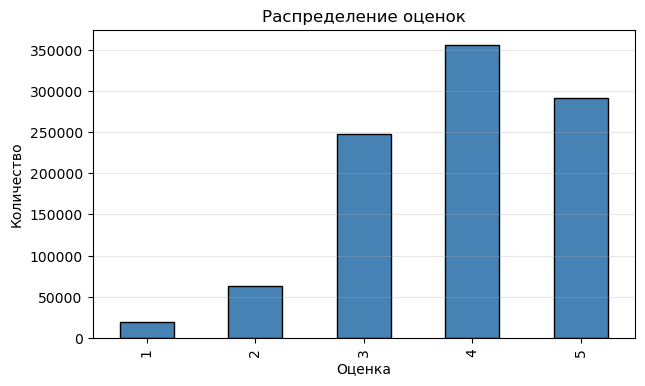

Средняя оценка: 3.86

Распределение оценок (в долях):
rating
1    0.019939
2    0.064438
3    0.253343
4    0.364092
5    0.298187
Name: proportion, dtype: float64

АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ:
Среднее число оценок на пользователя: 18.3
Медиана: 8.0
Максимум: 200
Пользователей с 1 оценкой: 42


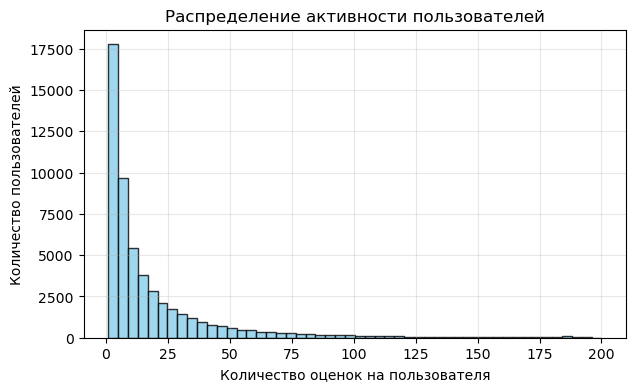


ПОПУЛЯРНОСТЬ КНИГ:
Среднее число оценок на книгу: 97.9
Медиана: 100.0
Максимум: 100
Книг с 1 оценкой: 0


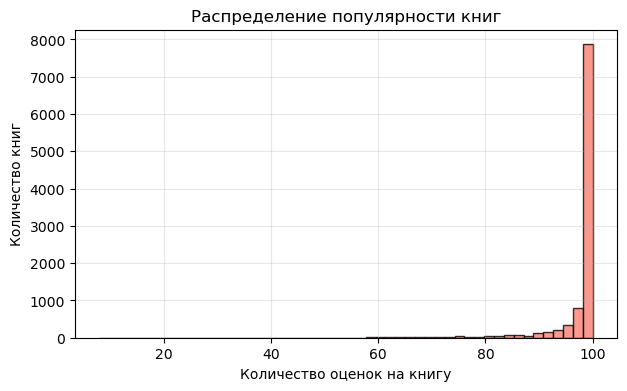

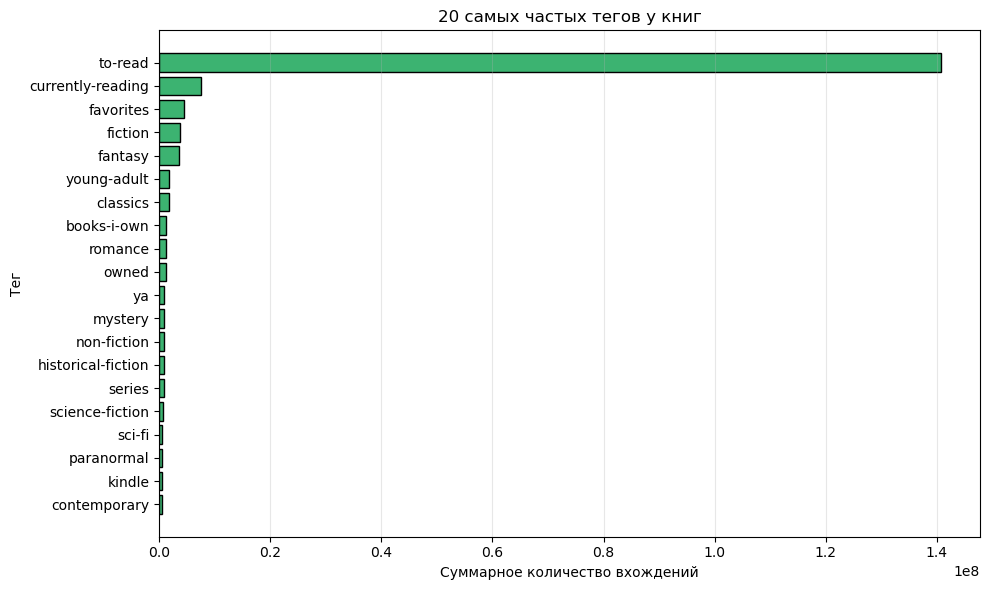


Анализ данных завершен.


In [15]:
# Основная статистика
n_users = ratings['user_id'].nunique()
n_books = ratings['book_id'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_books))

print("ОСНОВНАЯ СТАТИСТИКА:")
print(f"уникальных пользователей: {n_users:,}")
print(f"уникальных книг: {n_books:,}")
print(f"всего оценок: {n_ratings:,}")
print(f"разреженность матрицы: {sparsity:.4%}")


# Распределение оценок
plt.figure(figsize=(7, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Проверим смещение в сторону высоких оценок
mean_rating = ratings['rating'].mean()
print(f"Средняя оценка: {mean_rating:.2f}")
rating_distribution = ratings['rating'].value_counts(normalize=True).sort_index()
print("\nРаспределение оценок (в долях):")
print(rating_distribution)

# Анализ активности пользователей
user_activity = ratings.groupby('user_id').size()
print("\nАКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ:")
print(f"Среднее число оценок на пользователя: {user_activity.mean():.1f}")
print(f"Медиана: {user_activity.median():.1f}")
print(f"Максимум: {user_activity.max()}")
print(f"Пользователей с 1 оценкой: {(user_activity == 1).sum():,}")

plt.figure(figsize=(7, 4))
plt.hist(user_activity, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
#plt.yscale('log')
plt.xlabel('Количество оценок на пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение активности пользователей')
plt.grid(True, alpha=0.3)
plt.show()

# Анализ популярности книг
book_popularity = ratings.groupby('book_id').size()
print("\nПОПУЛЯРНОСТЬ КНИГ:")
print(f"Среднее число оценок на книгу: {book_popularity.mean():.1f}")
print(f"Медиана: {book_popularity.median():.1f}")
print(f"Максимум: {book_popularity.max()}")
print(f"Книг с 1 оценкой: {(book_popularity == 1).sum():,}")

plt.figure(figsize=(7, 4))
plt.hist(book_popularity, bins=50, color='salmon', edgecolor='black', alpha=0.8)
# plt.yscale('log')
plt.xlabel('Количество оценок на книгу')
plt.ylabel('Количество книг')
plt.title('Распределение популярности книг')
plt.grid(True, alpha=0.3)
plt.show()

# Визуализация тегов
# Объединим book_tags и tags для получения названий тегов
tags_merged = book_tags.merge(tags, on='tag_id', how='left')
tag_counts = (
    tags_merged.groupby('tag_name', dropna=False)['count']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
plt.barh(tag_counts.index[::-1], tag_counts.values[::-1], color='mediumseagreen', edgecolor='black')
plt.title('20 самых частых тегов у книг')
plt.xlabel('Суммарное количество вхождений')
plt.ylabel('Тег')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nАнализ данных завершен.")




Основные выявленные проблемы:

* Высокая разреженность (99.8%) — осложняет обучение моделей, особенно классической коллаборативной фильтрации.
* Смещение оценок — большинство оценок положительные, что снижает контрастность сигналов.
* Проблема холодного старта — пользователи с 1–2 оценками и книги с небольшим числом взаимодействий.
* Смещение популярности — модели могут переоценивать популярные книги.

##### Выбор варианта раделения данных

In [16]:

# Случайное разделение данных
def split_random(ratings, test_size=0.2, random_state=42):
    start_time = time.time()

    # случайное разбиение датасета
    train, test = train_test_split(ratings, test_size=test_size, random_state=random_state)
    elapsed = time.time() - start_time

    # утечки нет (train и test не пересекаются напрямую)
    leakage = False

    return train, test, elapsed, leakage


# Разделение по порядку записей
def split_temporal_by_rating_order(ratings, test_ratio=0.2):
    start_time = time.time()

    # Сортируем по исходному индексу (имитируем хронологический порядок)
    ratings_sorted = ratings.reset_index().sort_values('index')

    # Определяем границу разделения
    split_idx = int(len(ratings_sorted) * (1 - test_ratio))
    train = ratings_sorted.iloc[:split_idx].copy()
    test  = ratings_sorted.iloc[split_idx:].copy()

    # Удаляем служебную колонку 'index', она больше не нужна
    train.drop(columns='index', inplace=True)
    test.drop(columns='index', inplace=True)

    elapsed = time.time() - start_time

    # утечки нет (train содержит только "прошлые" оценки)
    leakage = False

    return train, test, elapsed, leakage


# Hold-out последней оценки для каждого пользователя
def split_holdout_last_book(ratings):
    start_time = time.time()

    # Оставляем только пользователей с двумя и более оценками
    user_counts = ratings.groupby('user_id').size()
    valid_users = user_counts[user_counts >= 2].index
    ratings_valid = ratings[ratings['user_id'].isin(valid_users)]

    # Используем индекс как прокси-время и сортируем
    ratings_sorted = ratings_valid.reset_index().sort_values('index')

    # Для каждого пользователя берем последнюю запись в test
    last_ratings = ratings_sorted.groupby('user_id', group_keys=False).tail(1)
    test = last_ratings.copy()

    # Остальные записи — в train
    train = ratings_sorted.loc[~ratings_sorted.index.isin(last_ratings.index)].copy()

    # Удаляем служебную колонку
    train.drop(columns='index', inplace=True)
    test.drop(columns='index', inplace=True)

    elapsed = time.time() - start_time

    # Проверяем на утечки: тестовые оценки не должны идти раньше тренировочных
    leakage_found = False
    checked = 0
    for uid in test['user_id'].unique():
        user_train = ratings_sorted[
            (ratings_sorted['user_id'] == uid) &
            (~ratings_sorted.index.isin(last_ratings.index))
        ]
        if len(user_train) == 0:
            continue

        # Последний индекс в train и индекс тестовой записи
        user_train_max_idx = user_train['index'].max()
        user_test_idx = last_ratings[last_ratings['user_id'] == uid]['index'].iloc[0]

        # Если тестовая запись не строго позже — утечка
        if user_test_idx <= user_train_max_idx:
            leakage_found = True
            break

        checked += 1
        if checked >= 100:  # ограничим проверку для скорости
            break

    return train, test, elapsed, leakage_found


In [17]:
# тестируем все методы разделения
split_methods = [
    ('Случайное', split_random),
    ('По порядку оценок', split_temporal_by_rating_order),
    ('Hold-out последней книги', split_holdout_last_book)
]

split_results = []

for split_name, split_func in split_methods:
    print(f"тестируем: {split_name}")
    print("-" * 30)

    train_split, test_split, time_taken, leakage = split_func(ratings)

    # статистика разделения
    common_users = len(set(train_split['user_id']) & set(test_split['user_id']))
    common_books = len(set(train_split['book_id']) & set(test_split['book_id']))

    # Анализ холодных пользователей и книг (не утечка данных)
    new_users_in_test = len(set(test_split['user_id']) - set(train_split['user_id']))
    new_books_in_test = len(set(test_split['book_id']) - set(train_split['book_id']))

    split_results.append({
        'Метод': split_name,
        'Train размер': len(train_split),
        'Test размер': len(test_split),
        'Общие пользователи': common_users,
        'Общие книги': common_books,
        'Новые пользователи в тесте': new_users_in_test,
        'Новые книги в тесте': new_books_in_test,
        'Время (сек)': round(time_taken, 4),
        'Утечка данных': 'Да' if leakage else 'Нет'
    })

    print(f"  train: {len(train_split):,} записей")
    print(f"  test: {len(test_split):,} записей")
    print(f"  общие пользователи: {common_users:,}")
    print(f"  общие книги: {common_books:,}")
    print(f"  новые пользователи в тесте: {new_users_in_test:,}")
    print(f"  новые книги в тесте: {new_books_in_test:,}")
    print(f"  утечка данных: {'Да' if leakage else 'Нет'}")
    print()

# сравнение методов
split_df = pd.DataFrame(split_results)
print("\nСРАВНЕНИЕ МЕТОДОВ РАЗДЕЛЕНИЯ:")
print(split_df.to_string(index=False))

# выбираем метод без утечки данных
no_leakage_splits = split_df[split_df['Утечка данных'] == 'Нет']
if len(no_leakage_splits) > 0:
    best_split_name = no_leakage_splits.iloc[0]['Метод']
    print(f"\nВЫБРАН МЕТОД: {best_split_name} (нет утечки данных)")
else:
    best_split_name = 'Случайное'
    print(f"\nВСЕ МЕТОДЫ ИМЕЮТ УТЕЧКУ, ВЫБИРАЕМ: {best_split_name}")

# создаем финальное разделение
if best_split_name == 'Случайное':
    train, test, _, _ = split_random(ratings)
elif best_split_name == 'По порядку оценок':
    train, test, _, _ = split_temporal_by_rating_order(ratings)
else:
    train, test, _, _ = split_holdout_last_book(ratings)

print(f"\nФИНАЛЬНОЕ РАЗДЕЛЕНИЕ ({best_split_name}):")
print(f"  train: {len(train):,} записей")
print(f"  test: {len(test):,} записей")
print(f"  Пользователей в train: {train['user_id'].nunique():,}")
print(f"  Пользователей в test: {test['user_id'].nunique():,}")
print(f"  Книг в train: {train['book_id'].nunique():,}")
print(f"  Книг в test: {test['book_id'].nunique():,}")
print(f"  Общие пользователи: {len(set(train['user_id']) & set(test['user_id'])):,}")
print(f"  Общие книги: {len(set(train['book_id']) & set(test['book_id'])):,}")

# подготовка данных для оценки рекомендательной системы
all_books = ratings['book_id'].unique()
user_seen_books = train.groupby('user_id')['book_id'].agg(set).to_dict()
common_users = set(test['user_id']) & set(train['user_id'])
test_filtered = test[test['user_id'].isin(common_users)]

print(f"  Пользователей для оценки: {len(common_users):,}")
print(f"  Книг для рекомендаций: {len(all_books):,}")

# Дополнительная статистика по книгам
print("\nИНФОРМАЦИЯ О КНИГАХ:")
print(f"  Всего уникальных книг в данных: {len(all_books):,}")
print(f"  Книг с заполненными названиями: {books['original_title'].notna().sum():,}")


тестируем: Случайное
------------------------------
  train: 783,582 записей
  test: 195,896 записей
  общие пользователи: 39,981
  общие книги: 10,000
  новые пользователи в тесте: 439
  новые книги в тесте: 0
  утечка данных: Нет

тестируем: По порядку оценок
------------------------------
  train: 783,582 записей
  test: 195,896 записей
  общие пользователи: 44,557
  общие книги: 1
  новые пользователи в тесте: 5,095
  новые книги в тесте: 2,081
  утечка данных: Нет

тестируем: Hold-out последней книги
------------------------------
  train: 926,054 записей
  test: 53,382 записей
  общие пользователи: 53,382
  общие книги: 3,449
  новые пользователи в тесте: 0
  новые книги в тесте: 8
  утечка данных: Нет


СРАВНЕНИЕ МЕТОДОВ РАЗДЕЛЕНИЯ:
                   Метод  Train размер  Test размер  Общие пользователи  Общие книги  Новые пользователи в тесте  Новые книги в тесте  Время (сек) Утечка данных
               Случайное        783582       195896               39981        10000     

Сравнение методов разбиения:

Случайное

* Хорошее пересечение книг (10 000) и пользователей (39 981), но в тесте есть 439 новых пользователей.
* Подходит для неперсонализированных и простых моделей, но не отражает сценарий «следующая оценка» и даёт перекрёстную информацию между периодами.

По порядку оценок (псевдо-временной)

* Очень сильный сдвиг: в тесте 5 095 новых пользователей и 2 081 новых книг; общих книг всего 1.
* Такой разрез почти не пригоден для офлайн-оценки персонализированных моделей: сильный холодный старт и распределительный разрыв.

Hold-out последней книги

* Идеален для персонализации: 53 382 общих пользователей (полное совпадение), минимальный холодный старт по книгам (8 новых).
* Наиболее реалистично проверяет задачу «предсказать следующую оценку пользователя».

Вывод: выбираем Hold-out последней книги как основной метод разбиения данных для дальнейшего моделирования и оценки.

### Этап 2: базовые и контентные модели

#### 1. Неперсонализированная модель: алгоритм, возвращающий Top-N самых популярных книг (по среднему рейтингу с порогом минимального количества оценок).

In [18]:
class PopularityRecommender:
    """рекомендации на основе популярности"""

    def __init__(self, min_ratings=50):
        self.min_ratings = min_ratings
        self.popular_books = None

    def fit(self, train_data):
        """обучение модели"""
        print("обучение popularity модели...")

        # рассчитываем средний рейтинг и количество оценок
        book_stats = (
            train_data.groupby('book_id')['rating']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'mean_rating', 'count': 'num_ratings'})
            .reset_index()
        )

        # фильтрация по минимальному количеству оценок
        filtered = book_stats[book_stats['num_ratings'] >= self.min_ratings]

        # сортировка по среднему рейтингу и числу оценок
        filtered = filtered.sort_values(by=['mean_rating', 'num_ratings'], ascending=False)

        # сохраняем список популярных книг
        self.popular_books = filtered['book_id'].tolist()

        print(f"Модель обучена. Книг с минимум {self.min_ratings} оценками: {len(self.popular_books)}")

    def recommend(self, user_seen_books, k=10):
        """рекомендует книги, которых пользователь еще не видел"""
        if not self.popular_books:
            return []

        seen_set = set(user_seen_books)
        recs = []
        for book in self.popular_books:
            if book not in seen_set:
                recs.append(book)
                if len(recs) >= k:
                    break
        return recs

    def get_top_popular_books(self, n=10):
        """Возвращает топ-N популярных книг (по среднему рейтингу с фильтром по количеству оценок)"""
        if self.popular_books is None:
            return []
        return self.popular_books[:n]

In [19]:
# создаем и обучаем модель
pop_model = PopularityRecommender(min_ratings=10)
pop_model.fit(train)

# получаем топ-10 популярных книг
top_books = pop_model.get_top_popular_books(n=10)
print("ТОП-10 популярных книг:", top_books)

# рекомендации для конкретного пользователя
example_user = train['user_id'].iloc[0]
user_seen = train[train['user_id'] == example_user]['book_id'].tolist()
print("Рекомендации пользователю:", pop_model.recommend(user_seen, k=5))


обучение popularity модели...
Модель обучена. Книг с минимум 10 оценками: 9999
ТОП-10 популярных книг: [7947, 5207, 9566, 8978, 6920, 3275, 8663, 3753, 6361, 4483]
Рекомендации пользователю: [7947, 5207, 9566, 8978, 6920]


#### 2. Контентная модель:

##### Объединнеие данных о книгах с их тегами. Для каждой книги текстовый «профиль» из названия (original_title) и списка тегов.
##### Векторизуйте эти профили с помощью TF-IDF.
##### Реализуйте функцию get_similar_books(book_id, N=5), которая находит N самых похожих книг по косинусной мере близости между их TF-IDF-векторами.

In [20]:
# Контентная модель на основе TF-IDF по названиям и тегам
class ContentBasedRecommender:

    def __init__(self):
        self.tfidf_vectorizer = None
        self.tfidf_matrix = None
        self.book_profiles = None
        self.book_id_to_index = None
        self.book_ids = None

    # Объединяет книги и теги, создает текстовые профили и обучает TF-IDF векторизацию.
    def fit(self, books, book_tags, tags):     
        print("Обучение Content-Based модели...")

        # Объединяем book_tags и tags, чтобы добавить текст тегов
        book_tags_merged = book_tags.merge(tags, on='tag_id', how='left')

        # Собираем топ-теги для каждой книги
        book_tag_strings = (
            book_tags_merged.groupby('goodreads_book_id')['tag_name']
            .apply(lambda x: ' '.join(x.astype(str).values))
            .reset_index()
        )

        # Объединяем книги с их тегами
        books_with_tags = books.merge(
            book_tag_strings,
            left_on='best_book_id',
            right_on='goodreads_book_id',
            how='left'
        )

        # Создаем текстовый профиль: title + теги
        books_with_tags['profile'] = (
            books_with_tags['original_title'].fillna('') + ' ' +
            books_with_tags['tag_name'].fillna('')
        )

        # Векторизация профилей TF-IDF
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words='english'
        )
        self.tfidf_matrix = self.tfidf_vectorizer.fit_transform(books_with_tags['profile'])

        # сохраняем справочники
        self.book_ids = books_with_tags['book_id'].values
        self.book_id_to_index = {book_id: idx for idx, book_id in enumerate(self.book_ids)}
        self.book_profiles = books_with_tags[['book_id', 'original_title', 'profile']]

        print(f"Модель обучена на {len(self.book_ids)} книгах.")

    # Возвращает N наиболее похожих книг по косинусному сходству TF-IDF-векторов.
    def get_similar_books(self, book_id, N=5):
        if book_id not in self.book_id_to_index:
            print(f"Книга с book_id={book_id} не найдена в модели.")
            return []

        idx = self.book_id_to_index[book_id]
        book_vector = self.tfidf_matrix[idx]

        # рассчитываем схожесть со всеми книгами
        similarities = cosine_similarity(book_vector, self.tfidf_matrix).flatten()
        similar_indices = np.argsort(-similarities)[1:N+1]  # исключаем саму книгу (индекс 0)

        similar_books = [
            {
                'book_id': int(self.book_ids[i]),
                'title': self.book_profiles.iloc[i]['original_title'],
                'similarity': round(float(similarities[i]), 4)
            }
            for i in similar_indices
        ]

        return similar_books

In [21]:
# создаем и обучаем модель
cb_model = ContentBasedRecommender()
cb_model.fit(books, book_tags, tags)

# выбираем случайную книгу
example_book = books['book_id'].iloc[3]
print(f"Похожие книги для: {books.loc[books['book_id'] == example_book, 'original_title'].values[0]}")

# получаем топ-5 похожих
similar_books = cb_model.get_similar_books(example_book, N=5)
pd.DataFrame(similar_books)


Обучение Content-Based модели...
Модель обучена на 10000 книгах.
Похожие книги для: To Kill a Mockingbird


,book_id,title,similarity
0,4671,The Great Gatsby,0.8200
1,5107,The Catcher in the Rye,0.8127
2,7624,Lord of the Flies,0.7850
3,890,Of Mice and Men,0.7759
4,37415,Their Eyes Were Watching God,0.7049


### Этап 3: коллаборативная фильтрация (Collaborative Filtering — CF)

#### 1. Строим матрицу взаимодействий «пользователь — книга» (user_id x book_id). Значениями могут быть явные оценки (rating) или неявный feedback (например, 1, если оценка ≥ 4, иначе 0).

#### 2. Реализуем Item-Based Collaborative Filtering:

##### Рассчет матрицы попарных схожестей между книгами (например, с помощью коэффициента корреляции Пирсона или косинусной близости по векторам оценок).

In [22]:
# Item-Item Collaborative Filtering, similarity_metric: 'cosine' или 'pearson'
class ItemBasedCF:

    def __init__(self, k_neighbors=50, similarity_metric='cosine', implicit=False, rel_threshold=4):
        assert similarity_metric in ('cosine', 'pearson')
        self.k_neighbors = k_neighbors
        self.similarity_metric = similarity_metric
        self.implicit = implicit
        self.rel_threshold = rel_threshold

        # Маппинги id - index
        self.user2idx = None
        self.idx2user = None
        self.item2idx = None
        self.idx2item = None

        # Разреженные матрицы
        self.R = None     
        self.Rc = None        

        # Соседи itemов
        self.nbrs_index = None   
        self.nbrs_sim = None     

        # Глобальные статистики
        self.global_mean = None

    def _build_id_maps(self, ratings):
        users = ratings['user_id'].unique()
        items = ratings['book_id'].unique()

        self.user2idx = {u: i for i, u in enumerate(users)}
        self.idx2user = np.array(users)
        self.item2idx = {it: j for j, it in enumerate(items)}
        self.idx2item = np.array(items)

    def _build_sparse_matrix(self, ratings):
        # бинаризация при implicit
        vals = ratings['rating'].values.astype(float)
        if self.implicit:
            vals = (vals >= self.rel_threshold).astype(float)

        rows = ratings['user_id'].map(self.user2idx).values
        cols = ratings['book_id'].map(self.item2idx).values
        n_users = len(self.user2idx)
        n_items = len(self.item2idx)

        self.R = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items), dtype=float)
        self.global_mean = float(np.mean(vals)) if len(vals) > 0 else 0.0

    @staticmethod
    # Центрирует каждую строку CSR-матрицы по среднему ненулевых значений. Возвращает CSR той же формы.
    def _row_center_csr(mat: csr_matrix):
    
        mat = mat.tocsr().copy()

        # сумма по строкам и количество ненулевых по строкам
        sums = np.array(mat.sum(axis=1)).ravel()
        nnz = np.diff(mat.indptr)
        # избегаем деления на ноль
        means = np.zeros_like(sums, dtype=float)
        nonzero_mask = nnz > 0
        means[nonzero_mask] = sums[nonzero_mask] / nnz[nonzero_mask]

        # вычитаем среднее из ненулевых элементов каждой строки
        data = mat.data
        for i in range(mat.shape[0]):
            start, end = mat.indptr[i], mat.indptr[i+1]
            if start == end:
                continue
            data[start:end] = data[start:end] - means[i]
        return mat
    #  Обучает поиск соседей по item-векторам
    def _fit_neighbors(self):
        
        if self.similarity_metric == 'cosine':
            item_matrix = self.R.T  # shape: n_items x n_users (sparse CSR)
        else:  # 'pearson'
            if self.Rc is None:
                self.Rc = self._row_center_csr(self.R)
            item_matrix = self.Rc.T

        nn = NearestNeighbors(
            n_neighbors=min(self.k_neighbors + 1, item_matrix.shape[0]),
            metric='cosine',
            algorithm='brute',
            n_jobs=-1
        )
        nn.fit(item_matrix)

        # для каждого item получим соседей и расстояния
        distances, indices = nn.kneighbors(item_matrix, return_distance=True)
        distances = distances[:, 1:]
        indices = indices[:, 1:]
        # конвертируем расстояния в сходства
        sims = 1.0 - distances

        self.nbrs_index = indices.astype(np.int32)
        self.nbrs_sim = sims.astype(np.float32)

    # ratings: DataFrame с колонками ['user_id', 'book_id', 'rating']
    def fit(self, ratings: pd.DataFrame):
        
        print("Обучение Item-Based CF (sparse + top-K)...")
        ratings = ratings[['user_id', 'book_id', 'rating']].copy()
        self._build_id_maps(ratings)
        self._build_sparse_matrix(ratings)
        if self.similarity_metric == 'pearson':
            self.Rc = self._row_center_csr(self.R)
        self._fit_neighbors()

        n_users, n_items = self.R.shape
        print(f"Матрица взаимодействий: {n_users} пользователей × {n_items} книг")
        print(f"Соседи рассчитаны: top-{self.k_neighbors} на метрике {self.similarity_metric}")

    # Предсказание для пользователя u_idx и item i_idx по его top-K соседям.
    def _predict_from_neighbors(self, u_idx: int, i_idx: int):

        if self.nbrs_index is None:
            return np.nan

        # соседи целевого item
        nbr_idx = self.nbrs_index[i_idx]
        nbr_sim = self.nbrs_sim[i_idx]

        # какие из соседей пользователь оценивал
        user_row = self.R.getrow(u_idx)  # CSR 1 x n_items
        rated_items = user_row.indices
        rated_mask = np.isin(nbr_idx, rated_items)

        if not np.any(rated_mask):
            return np.nan

        nbr_idx_rated = nbr_idx[rated_mask]
        nbr_sim_rated = nbr_sim[rated_mask]

        # вытаскиваем соответствующие оценки пользователя для этих соседей
        user_data = dict(zip(rated_items, user_row.data))
        ratings_vec = np.array([user_data[j] for j in nbr_idx_rated], dtype=float)

        # взвешенное среднее по сходствам
        num = np.sum(nbr_sim_rated * ratings_vec)
        denom = np.sum(np.abs(nbr_sim_rated)) + 1e-12
        return float(num / denom)

    #  Возвращает предсказанный рейтинг.
    def predict_rating(self, user_id, book_id):
        
        if user_id not in self.user2idx or book_id not in self.item2idx:
            return np.nan
        u_idx = self.user2idx[user_id]
        i_idx = self.item2idx[book_id]

        # если пользователь уже оценивал item, можно вернуть его фактическую оценку
        val = self.R[u_idx, i_idx]
        if val != 0:
            return float(val)

        pred = self._predict_from_neighbors(u_idx, i_idx)
        if np.isnan(pred):
            return self.global_mean
        return pred

    # Рекомендует top-k книг пользователю.
    def recommend(self, user_id, k=10):
       
        if user_id not in self.user2idx:
            
            return []

        u_idx = self.user2idx[user_id]
        user_row = self.R.getrow(u_idx)
        rated_items = set(user_row.indices.tolist())

        # если пользователь ничего не оценивал — пусто
        if not rated_items:
            return []

        # кандидаты: соседи уже оцененных книг пользователя
        candidate_set = set()
        for j in rated_items:
            candidate_set.update(self.nbrs_index[j].tolist())

        # исключим уже виденные
        candidate_set -= rated_items
        if not candidate_set:
            return []

        # скорим кандидатов
        scores = []
        for i_idx in candidate_set:
            pred = self._predict_from_neighbors(u_idx, i_idx)
            if not np.isnan(pred):
                scores.append((i_idx, pred))

        if not scores:
            return []

        scores.sort(key=lambda x: x[1], reverse=True)
        top = scores[:k]
        return [int(self.idx2item[i]) for i, _ in top]


##### Для заданной книги и пользователя предсказываем оценку, усредняя оценки пользователя по K наиболее похожим книгам.

In [23]:
# обучаем
cf_model = ItemBasedCF(k_neighbors=50, similarity_metric='cosine', implicit=False)
cf_model.fit(train)

# предсказать
user_example = train['user_id'].iloc[0]
book_example = train['book_id'].iloc[10]
pred = cf_model.predict_rating(user_example, book_example)

# рекомендации
recs = cf_model.recommend(user_example, k=5)
print("Рекомендованные книги:", recs[:5])

Обучение Item-Based CF (sparse + top-K)...
Матрица взаимодействий: 52985 пользователей × 10000 книг
Соседи рассчитаны: top-50 на метрике cosine
Рекомендованные книги: [3546, 446, 9841, 1515, 2018]


##### 3. В чём вычислительная сложность этого подхода? Как его можно оптимизировать для больших данных?

Cейчас метод считает слишком много лишнего — сравнивает все книги со всеми , что даёт сложность O(I^2*U). Чтобы сделать его быстрым и подходящим для больших данных:

* считать сходства только с ограниченным числом соседей (top-K),
* использовать косинус и разреженные матрицы,
* фильтровать редкие книги



### Этап 4: матричные разложения (Matrix Factorization)

#### Более продвинутые и масштабируемые методы предсказания оценок.

##### 1. Используйте библиотеку surprise для обучения модели SVD или любую другую библиотеку с данным алгоритмом.
##### 2. Разделите данные на обучающую и тестовую выборку. Обучите модель и оцените ошибку предсказания (RMSE) на тесте.

In [24]:
# Переменные train и test уже существуют

# Подготовка данных для surprise
def prepare_surprise_data(train_df, test_df, rating_col='rating'):
    # приведение типов
    tr = train_df[['user_id', 'book_id', rating_col]].copy()
    te = test_df[['user_id', 'book_id', rating_col]].copy()
    tr['user_id'] = tr['user_id'].astype(str)
    tr['book_id'] = tr['book_id'].astype(str)
    te['user_id'] = te['user_id'].astype(str)
    te['book_id'] = te['book_id'].astype(str)
    tr[rating_col] = tr[rating_col].astype(float)
    te[rating_col] = te[rating_col].astype(float)

    # фильтрация теста по пересечению пользователей и книг из train
    train_users = set(tr['user_id'])
    train_items = set(tr['book_id'])
    test_filtered = te[te['user_id'].isin(train_users) & te['book_id'].isin(train_items)].copy()

    # surprise объекты
    reader = Reader(rating_scale=(1, 5))
    data = dts.load_from_df(tr[['user_id', 'book_id', rating_col]], reader)
    trainset = data.build_full_trainset()

    # testset = список троек (uid, iid, true_rating)
    testset = list(zip(
        test_filtered['user_id'].tolist(),
        test_filtered['book_id'].tolist(),
        test_filtered[rating_col].tolist()
    ))

    # справочные структуры для рекомендаций
    user_seen_books = train_df.groupby('user_id')['book_id'].agg(set).to_dict()
    all_books = np.union1d(train_df['book_id'].unique(), test_df['book_id'].unique())

    print("Данные для SVD подготовлены:")
    print(f"  train: {len(tr):,} строк | users: {len(train_users):,} | items: {len(train_items):,}")
    print(f"  test (filtered): {len(test_filtered):,} строк | users: {test_filtered['user_id'].nunique():,}\
           | items: {test_filtered['book_id'].nunique():,}")

    return trainset, testset, user_seen_books, all_books

# Обучение SVD и оценка RMSE
trainset, testset, user_seen_books, all_books = prepare_surprise_data(train, test)

algo = SVD(
    n_factors=100,   # размерность латентного пространства
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.03,
    random_state=42
)
algo.fit(trainset)

predictions = algo.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)
print(f"RMSE (SVD) на тесте: {rmse:.4f}")

# Рекомендер на базе обученного SVD
class SVDRecommender:
   
    def __init__(self, algo, train_df, all_books, fallback_topn=100):
        self.algo = algo
        self.all_books = np.array(all_books)  # массив book_id (str или int)
        # история пользователя из train для фильтрации уже виденных книг
        self.user_seen = train_df.groupby('user_id')['book_id'].agg(set).to_dict()
        # простой fallback — популярные книги по train
        self.popular_books = (
            train_df['book_id'].value_counts().index.tolist()[:fallback_topn]
        )


    # если пользователь присутствовал в train: ранжируем все невиданные книги по предсказанному рейтингу
    # если cold-start: возвращаем популярные книги
    def get_recommendations(self, user_id, N=5):
       
        uid_str = str(user_id)

        # проверяем, есть ли пользователь в тренировочном словаре internal id
        try:
            _ = self.algo.trainset.to_inner_uid(uid_str)
            user_in_train = True
        except ValueError:
            user_in_train = False

        if not user_in_train:
            return self.popular_books[:N]

        seen = self.user_seen.get(user_id, set())
        candidates = [b for b in self.all_books if b not in seen]

        # surprise ожидает строки в predict
        def _to_str(x):
            return str(x)

        scored = []
        for bid in candidates:
            est = self.algo.predict(uid_str, _to_str(bid), verbose=False).est
            scored.append((bid, est))

        topN = sorted(scored, key=lambda x: x[1], reverse=True)[:N]
        return [bid for bid, _ in topN]


Данные для SVD подготовлены:
  train: 783,582 строк | users: 52,985 | items: 10,000
  test (filtered): 194,959 строк | users: 39,981           | items: 10,000
RMSE (SVD) на тесте: 0.8396


In [25]:
# Пример использования рекомендера
svd_rec = SVDRecommender(algo, train[['user_id','book_id','rating']], all_books)

example_user = train['user_id'].iloc[0]
top5 = svd_rec.get_recommendations(example_user, N=5)
print("Пример топ-5 рекомендаций для пользователя", example_user, ":", top5)

Пример топ-5 рекомендаций для пользователя 42006 : [6590, 4868, 6920, 5207, 9566]


### Этап 5: оценка и сравнение моделей
##### Сравниваем качество всех реализованных моделей объективными метриками.

#### 1. Для моделей, которые возвращают топ-N рекомендаций (Popularity, Item-Based CF, SVD), рассчитываем метрики качества:
##### Precision@K
##### Recall@K
##### nDCG@K (Normalized Discounted Cumulative Gain)
#### 2. В качестве релевантных items считаем книги, которым пользователь поставил оценку выше порога (например, ≥ 4).
#### 3. Проведем оценку на отложенной тестовой выборке (не участвовавшей в обучении)

In [26]:
# Используем уже готовое hold-out разбиение train/test и обученные модели pop_model, cf_model, svd_rec

# истории и каталог
all_books_eval = np.union1d(train['book_id'].unique(), test['book_id'].unique())
user_seen_eval = train.groupby('user_id')['book_id'].agg(set).to_dict()

# Готовим пользователей для оценки: только те, кто есть и в train, и в test, и имеет оценку ≥ 4
REL_THRESHOLD = 4
test_rel = test[test['rating'] >= REL_THRESHOLD].copy()

# Пользователи для оценки: есть в train и имеют релевант в test
users_in_train = set(train['user_id'].unique())
users_with_rels = set(test_rel['user_id'].unique())
eligible_users = sorted(users_in_train & users_with_rels)

# Оцениваем всех
import multiprocessing
SAMPLE_RATIO = 1.0
eval_users_sample = eligible_users  # полный датасет
print(f"Оцениваем {len(eval_users_sample)} пользователей из {len(eligible_users)} ({int(SAMPLE_RATIO*100)}%)")

K = 10
N_JOBS = max(1, multiprocessing.cpu_count() - 1)

# словарь релевантов из теста
user_true = test_rel.groupby('user_id')['book_id'].agg(list).to_dict()

# разобьём пользователей на чанки
chunks = np.array_split(np.array(eval_users_sample), min(N_JOBS, len(eval_users_sample)))

# Унифицированный вызов под 3 модели
def get_recs_unified(model, user_id, k): 
    if hasattr(model, "get_recommendations"):
        return model.get_recommendations(user_id, N=k)
    if hasattr(model, "recommend"):
        # ItemCF ожидает user_id; Popularity — user_history
        name = type(model).__name__.lower()
        if "popularity" in name:
            history = user_seen_eval.get(user_id, set())
            return model.recommend(history, k=k)
        else:
            return model.recommend(user_id, k=k)
    return []

# Функция: оценка одной группы (чанка) пользователей
def eval_chunk(model, user_ids, k):
    # Инициализация накопителей для метрик
    precision_sum = recall_sum = ndcg_sum = 0.0
    hit_sum = 0
    covered = set() 
    cnt = 0  

    for u in user_ids:
        # Получаем релевантные книги пользователя из теста (рейтинг >= 4)
        true_set = set(user_true.get(int(u), []))
        if not true_set:
            continue  

        # Получаем топ-K рекомендаций для пользователя
        recs = get_recs_unified(model, int(u), k)
        if not recs:
            continue

        # Убираем возможные NaN и приводим к int
        recs = [int(x) for x in recs if pd.notna(x)]
        if not recs:
            continue

        # Пользователь прошел оценку
        cnt += 1
        covered.update(recs)

        # Подсчет пересечения релевантных и рекомендованных
        hits = len(set(recs) & true_set)

        # Precision = доля релевантных среди рекомендованных
        precision_sum += hits / len(recs)

        # Recall = доля найденных релевантных среди всех релевантных
        recall_sum += hits / len(true_set)

        # Hit rate = хотя бы один релевант в топ-K (0 или 1)
        hit_sum += 1 if hits > 0 else 0

        # nDCG: учитывает позиции релевантных книг в списке
        rel = [1 if b in true_set else 0 for b in recs]
        if any(rel):
            dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))
            ideal = sorted(rel, reverse=True)
            idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal))
            ndcg_sum += (dcg / idcg) if idcg > 0 else 0.0

    # Возвращаем накопленные результаты по чанку
    return {
        "p": precision_sum,
        "r": recall_sum,
        "ndcg": ndcg_sum,
        "hit": hit_sum,
        "cnt": cnt,
        "covered": covered
    }


# Функция: объединяет результаты всех чанков в единые метрики
def aggregate_parts(parts, catalog_size):
    # Суммируем частичные результаты
    p = sum(p["p"] for p in parts)
    r = sum(p["r"] for p in parts)
    ndcg = sum(p["ndcg"] for p in parts)
    hit = sum(p["hit"] for p in parts)
    cnt = sum(p["cnt"] for p in parts)

    # Собираем все рекомендованные книги для оценки coverage
    covered = set().union(*[p["covered"] for p in parts]) if parts else set()

    # Усредняем по пользователям и вычисляем финальные метрики
    return {
        f"precision@{K}": (p / cnt) if cnt else 0.0,
        f"recall@{K}": (r / cnt) if cnt else 0.0,
        f"ndcg@{K}": (ndcg / cnt) if cnt else 0.0,
        f"hit_rate@{K}": (hit / cnt) if cnt else 0.0,
        "coverage": (len(covered) / catalog_size) if catalog_size else 0.0,
        "users_evaluated": cnt
    }


# Функция: параллельная оценка модели
def parallel_eval_model(model, name):
    # Параллельно запускаем eval_chunk для каждого чанка пользователей
    parts = Parallel(n_jobs=N_JOBS)(
        delayed(eval_chunk)(model, ch, K) for ch in chunks
    )

    # Объединяем все частичные результаты
    res = aggregate_parts(parts, len(all_books_eval))

    # Выводим статистику
    print(f"{name}: пользователей оценено {res['users_evaluated']}")

    return res



Оцениваем 34288 пользователей из 34288 (100%)


####   4. Создайте сводную таблицу с метриками для всех моделей.

In [27]:
results = {}
results['Popularity'] = parallel_eval_model(pop_model, "Popularity")
results['ItemCF'] = parallel_eval_model(cf_model, "ItemCF")
results['SVD'] = parallel_eval_model(svd_rec, "SVD")
metrics_df = pd.DataFrame(results).T
metrics_df

Popularity: пользователей оценено 34288
ItemCF: пользователей оценено 34288
SVD: пользователей оценено 34288


,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,users_evaluated
Popularity,0.000563,0.001688,0.002347,0.004958,0.0019,34288.0
ItemCF,0.017685,0.085142,0.087197,0.156294,0.9994,34288.0
SVD,0.000639,0.001548,0.002806,0.005920,0.1519,34288.0


# Итоговый проект (PJ)
### Этап 1. Улучшенная подготовка данных
#### Создание расширенных признаков: 
##### Признаки пользователей: средний рейтинг, количество оценок, активность.

In [28]:
# Средний рейтинг, количество оценок, активность (нормированная)
user_features = (
    ratings.groupby('user_id')['rating']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'user_mean_rating', 'count': 'user_num_ratings'})
    .reset_index()
)

# Активность — нормировка по количеству оценок
user_features['user_activity'] = (
    user_features['user_num_ratings'] / user_features['user_num_ratings'].max()
)

print("Признаки пользователей сформированы:", user_features.shape)
user_features.head()

Признаки пользователей сформированы: (53424, 4)


,user_id,user_mean_rating,user_num_ratings,user_activity
0,1,3.666667,3,0.015
1,2,4.333333,3,0.015
2,3,1.000000,2,0.010
3,4,4.000000,3,0.015
4,5,4.200000,5,0.025


##### Признаки книг: популярность, разнообразие оценок, тематические категории.

In [29]:
# Популярность, средний рейтинг, разнообразие оценок (стандартное отклонение)
book_features = (
    ratings.groupby('book_id')['rating']
    .agg(['mean', 'count', 'std'])
    .rename(columns={
        'mean': 'book_mean_rating',
        'count': 'book_num_ratings',
        'std': 'book_rating_std'
    })
    .reset_index()
)

# std 0.0 для книг с одной оценкой
book_features['book_rating_std'] = book_features['book_rating_std'].fillna(0.0)


# Тематические категории  по тегам
tags_merged = book_tags.merge(tags, on='tag_id', how='left')
book_tag_text = (
    tags_merged.groupby('goodreads_book_id')['tag_name']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index()
)

books_with_tags = books.merge(
    book_tag_text, left_on='best_book_id', right_on='goodreads_book_id', how='left'
)
books_with_tags['tag_name'] = books_with_tags['tag_name'].fillna('')


# Векторизация тегов TF-IDF
tfidf_tags = TfidfVectorizer(max_features=1000, stop_words='english')
tag_matrix = tfidf_tags.fit_transform(books_with_tags['tag_name'])

# Построение матрицы теговых признаков с корректным столбцом book_id
tag_cols = [f"tag_{t}" for t in tfidf_tags.get_feature_names_out()]
book_topic_vector = pd.DataFrame(tag_matrix.toarray(), columns=tag_cols)
book_topic_vector.insert(0, 'book_id', books_with_tags['book_id'].values)

# На случай дублей оставляем первую строку на book_id
book_topic_vector = book_topic_vector.drop_duplicates(subset=['book_id'], keep='first')

# Гарантируем покрытие всех книг и отсутствие NaN в теговых колонках
all_book_ids = books['book_id'].unique()
book_topic_vector = (
    book_topic_vector.set_index('book_id')
    .reindex(all_book_ids) 
    .fillna(0.0)
    .reset_index()
)

# Объединяем числовые признаки книги с теговыми
book_features = book_features.merge(book_topic_vector, on='book_id', how='left')

# Финальное добивание пропусков (на случай редких краевых ситуаций)
tag_cols_in_book_features = [c for c in book_features.columns if c.startswith('tag_')]
book_features['book_rating_std'] = book_features['book_rating_std'].fillna(0.0)
book_features[tag_cols_in_book_features] = book_features[tag_cols_in_book_features].fillna(0.0)

# приведение теговых признаков к float32 для экономии памяти
book_features[tag_cols_in_book_features] = book_features[tag_cols_in_book_features].astype('float32')

print("Признаки книг сформированы:", book_features.shape)
book_features.head()


Признаки книг сформированы: (10000, 1004)


,book_id,book_mean_rating,book_num_ratings,book_rating_std,tag_100,tag_1000,tag_1001,tag_1800s,tag_18th,tag_1900s,...,tag_youngadult,tag_youth,tag_zombie,tag_zombies,tag_أدب,tag_روايات,tag_عربي,tag_عربية,tag_كتب,tag_مكتبتي
0,1,4.24,100,0.888990,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.077042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,4.21,100,1.037625,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.070532,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,3.09,100,1.470896,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.081046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,4.46,100,0.833879,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,3.89,100,1.072098,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.079799,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Признаки взаимодействий: схожесть с историей пользователя.

In [30]:
# соединяем рейтинги с векторами книг
ratings_with_vecs = ratings.merge(book_topic_vector, on='book_id', how='left')
ratings_with_vecs[tag_cols] = ratings_with_vecs[tag_cols].fillna(0.0)

# профиль пользователя — средний вектор прочитанных книг
user_profiles = (
    ratings_with_vecs.groupby('user_id')[tag_cols]
    .mean()
    .fillna(0.0)
)

# нормализация профилей
user_norms = np.linalg.norm(user_profiles.values, axis=1, keepdims=True)
user_norms[user_norms == 0] = 1.0
user_profiles = pd.DataFrame(
    user_profiles.values / user_norms,
    index=user_profiles.index,
    columns=tag_cols
)

# косинус и фичи взаимодействий
def safe_cosine(u: np.ndarray, v: np.ndarray) -> float:
    # защищаемся от NaN и нулевых норм
    if np.isnan(u).any() or np.isnan(v).any():
        return 0.0
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu == 0.0 or nv == 0.0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))

# насколько конкретная книга соответствует предпочтениям конкретного пользователя
def compute_interaction_features(ratings_df, user_profiles_df, book_vectors_df, topic_cols):
    book_vecs = book_vectors_df.set_index('book_id')[topic_cols]
    rows = []

    # ускоряем доступ к строкам
    uprof = user_profiles_df
    bmat = book_vecs

    for uid, bid, rating in ratings_df[['user_id', 'book_id', 'rating']].itertuples(index=False):
        if uid in uprof.index and bid in bmat.index:
            u = uprof.loc[uid].values
            v = bmat.loc[bid].values
            sim = safe_cosine(u, v)
        else:
            sim = 0.0
        rows.append((uid, bid, rating, sim))

    return pd.DataFrame(rows, columns=['user_id', 'book_id', 'rating', 'sim_with_user_profile'])

interaction_features = compute_interaction_features(
    ratings, user_profiles, book_topic_vector, tag_cols
)

print("Признаки взаимодействий сформированы:", interaction_features.shape)
interaction_features.head()

Признаки взаимодействий сформированы: (979478, 4)


,user_id,book_id,rating,sim_with_user_profile
0,314,1,5,0.739999
1,439,1,3,0.624999
2,588,1,5,0.599679
3,1169,1,4,0.692226
4,1185,1,4,0.592677


In [31]:
# Пересобираем итоговую таблицу признаков 

hybrid_features = (
    interaction_features
    .merge(
        ratings.groupby('user_id')['rating']
               .agg(user_mean_rating='mean', user_num_ratings='count')
               .assign(user_activity=lambda df: df['user_num_ratings']/df['user_num_ratings'].max()),
        on='user_id', how='left'
    )
    .merge(
        ratings.groupby('book_id')['rating']
               .agg(book_mean_rating='mean', book_num_ratings='count', book_rating_std='std')
               .fillna({'book_rating_std': 0.0})
               .reset_index(),
        on='book_id', how='left'
    )
    .merge(book_topic_vector, on='book_id', how='left')
)

print("Итоговая таблица признаков:", hybrid_features.shape)
hybrid_features

Итоговая таблица признаков: (979478, 1010)


,user_id,book_id,rating,sim_with_user_profile,user_mean_rating,user_num_ratings,user_activity,book_mean_rating,book_num_ratings,book_rating_std,...,tag_youngadult,tag_youth,tag_zombie,tag_zombies,tag_أدب,tag_روايات,tag_عربي,tag_عربية,tag_كتب,tag_مكتبتي
0,314,1,5,0.739999,3.585635,181,0.905,4.24,100,0.888990,...,0.0,0.077042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,439,1,3,0.624999,3.268571,175,0.875,4.24,100,0.888990,...,0.0,0.077042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,588,1,5,0.599679,3.618280,186,0.930,4.24,100,0.888990,...,0.0,0.077042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1169,1,4,0.692226,3.770053,187,0.935,4.24,100,0.888990,...,0.0,0.077042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1185,1,4,0.592677,3.473684,190,0.950,4.24,100,0.888990,...,0.0,0.077042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979473,48386,10000,5,0.000000,4.444444,18,0.090,4.00,96,0.820783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
979474,49007,10000,4,0.000000,3.625000,24,0.120,4.00,96,0.820783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
979475,49383,10000,5,0.000000,4.428571,14,0.070,4.00,96,0.820783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
979476,50124,10000,5,0.000000,4.470588,17,0.085,4.00,96,0.820783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Список новых признаков:

Признаки пользователей
* user_mean_rating — средний рейтинг пользователя.
* user_num_ratings — количество оценок, поставленных пользователем.
* user_activity — доля от максимального количества оценок среди всех пользователей.

Признаки книг
* book_mean_rating — средний рейтинг книги.
* book_num_ratings — количество оценок книги.
* book_rating_std — стандартное отклонение оценок (разброс).
* tag_* — тематические признаки книги, рассчитанные TF-IDF по тегам (1000 признаков вида tag_fantasy, tag_mystery, tag_romance и т.д.).

Признаки взаимодействий
* sim_with_user_profile — косинусное сходство между профилем пользователя и книгой, показывающее, насколько книга соответствует вкусам пользователя.

Эти признаки повышают качество рекомендаций, потому что дают модели больше контекста: она понимает, насколько активен и требователен пользователь, насколько популярна и тематически близка книга, и насколько конкретная книга соответствует вкусам пользователя. В итоге система становится более персонализированной и точной даже для новых пользователей и книг.

### Этап 2. Построение гибридной системы
#### 1. Стратегия объединения моделей:
##### Взвешенное усреднение предсказаний разных моделей.

In [32]:
LAMBDA_DIVERSITY = 0.8
# Безопасная нормализация списка (min-max по кандидатам)
def _minmax_normalize(scores_dict):
    if not scores_dict:
        return scores_dict
    vals = np.array(list(scores_dict.values()), dtype=float)
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    if np.isclose(vmin, vmax):
        return {k: 0.5 for k in scores_dict}  # все равны
    return {k: (float(v) - vmin) / (vmax - vmin) for k, v in scores_dict.items()}

# Получение сырых скорингов от моделей
def _scores_from_svd(user_id, candidates, svd_rec):
    # Возвращает предсказанные оценки SVD
    out = {}
    if svd_rec is None:
        return out
    uid_str = str(user_id)
    try:
        _ = svd_rec.algo.trainset.to_inner_uid(uid_str)
    except ValueError:
        return out
    for bid in candidates:
        est = svd_rec.algo.predict(uid_str, str(bid), verbose=False).est
        out[int(bid)] = float(est)
    return out

def _scores_from_itemcf(user_id, candidates, cf_model):
    # Предсказания itemCF
    out = {}
    if cf_model is None or user_id not in cf_model.user2idx:
        return out
    for bid in candidates:
        pr = cf_model.predict_rating(user_id, int(bid))
        if not np.isnan(pr):
            out[int(bid)] = float(pr)
    return out

def _scores_from_popularity(candidates, pop_model):
    # Преобразуем ранги популярности в скор
    out = {}
    if pop_model is None or not pop_model.popular_books:
        return out
    rank = {int(b): i for i, b in enumerate(pop_model.popular_books)}
    # Чем меньше ранг, тем выше score
    max_rank = max(rank.get(int(b), len(rank) + 1) for b in candidates) + 1
    for b in candidates:
        r = rank.get(int(b), max_rank)
        out[int(b)] = 1.0 - (r / max_rank)
    return out

# Контентный скор косинусное сходство профиля пользователя и тега книги
def _scores_from_content(user_id, candidates, user_profiles=None, book_topic_vector=None, tag_cols=None):
    out = {}
    if user_profiles is None or book_topic_vector is None or not tag_cols:
        return out
    if user_id not in user_profiles.index:
        return out
    u = user_profiles.loc[user_id, tag_cols].values
    # Предварительная нормализация
    u_norm = np.linalg.norm(u)
    if u_norm == 0:
        return out
    u = u / u_norm
    book_vecs = book_topic_vector.set_index('book_id')[tag_cols]
    for b in candidates:
        if int(b) not in book_vecs.index:
            continue
        v = book_vecs.loc[int(b)].values
        nv = np.linalg.norm(v)
        if nv == 0:
            continue
        out[int(b)] = float(np.dot(u, v / nv))
    return out

# Главная функция: blended score = sum_i w_i * norm(score_i)
def blended_scores(user_id, candidates, weights, svd_rec=None, cf_model=None, pop_model=None,
                   user_profiles=None, book_topic_vector=None, tag_cols=None):
    # Собираем сырые скоры
    s_svd  = _scores_from_svd(user_id, candidates, svd_rec) if weights.get('svd', 0) > 0 else {}
    s_cf   = _scores_from_itemcf(user_id, candidates, cf_model) if weights.get('itemcf', 0) > 0 else {}
    s_pop  = _scores_from_popularity(candidates, pop_model) if weights.get('pop', 0) > 0 else {}
    s_cont = _scores_from_content(user_id, candidates, user_profiles, book_topic_vector, tag_cols) if weights.get('content', 0) > 0 else {}

    # Нормализация по каждому источнику отдельно
    s_svd_n  = _minmax_normalize(s_svd)
    s_cf_n   = _minmax_normalize(s_cf)
    s_pop_n  = _minmax_normalize(s_pop)
    s_cont_n = _minmax_normalize(s_cont)

    # Итоговая смесь
    blended = {}
    for b in candidates:
        b = int(b)
        val = 0.0
        if b in s_svd_n:  val += weights.get('svd', 0.0)     * s_svd_n[b]
        if b in s_cf_n:   val += weights.get('itemcf', 0.0)  * s_cf_n[b]
        if b in s_pop_n:  val += weights.get('pop', 0.0)     * s_pop_n[b]
        if b in s_cont_n: val += weights.get('content', 0.0) * s_cont_n[b]
        blended[b] = val
    return blended


##### Разделение пользователей по типам (новые/активные).

In [33]:

# new — пользователь отсутствует в train или имеет меньше active_threshold оценок
# active — пользователь имеет достаточное количество оценок для персонализированных моделей

_user_counts = train.groupby('user_id').size().rename('num_ratings').to_dict()

def get_user_segment(user_id, active_threshold=5):
    
    if user_id not in _user_counts:
        return 'new'
    if _user_counts[user_id] < active_threshold:
        return 'new'
    return 'active'


##### Комбинирование персонализированных и популярных рекомендаций.

In [34]:

# Используем два сегмента пользователей new и active

# Каталог всех книг и история пользователей
_all_books_catalog = np.union1d(train['book_id'].unique(), test['book_id'].unique())
_seen_by_user = train.groupby('user_id')['book_id'].agg(set).to_dict()

# Веса моделей для каждого сегмента
SEGMENT_WEIGHTS = {
    # Новые пользователи — без истории, делаем упор на популярность и контент
    'new': {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'content': 0.3},
    # Активные пользователи — используем персонализированные модели
    'active': {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'content': 0.05},
}

def recommend_hybrid(user_id, k=10, candidate_mode='all', per_model_candidates=200):
    """
    Генерация гибридных рекомендаций:
      1. Определяем тип пользователя (new / active)
      2. Определяем веса моделей по сегменту
      3. Формируем пул кандидатов (весь каталог или объединение топов моделей)
      4. Считаем взвешенные blended_scores
      5. Фильтруем уже прочитанные книги
    """
    seg = get_user_segment(user_id)
    weights = SEGMENT_WEIGHTS.get(seg, SEGMENT_WEIGHTS['active'])
    seen = _seen_by_user.get(user_id, set())

    # Формирование кандидатов
    if candidate_mode == 'all':
        candidates = [b for b in _all_books_catalog if b not in seen]
    else:
        # Быстрая генерация кандидатов через топы моделей
        pool = set()

        # Популярные книги
        if pop_model is not None and getattr(pop_model, 'popular_books', None):
            for b in pop_model.popular_books[:per_model_candidates]:
                if b not in seen:
                    pool.add(int(b))

        # ItemCF: соседи книг, оцененных пользователем
        if cf_model is not None and user_id in getattr(cf_model, 'user2idx', {}):
            u_idx = cf_model.user2idx[user_id]
            rated_items = set(cf_model.R.getrow(u_idx).indices.tolist())
            for j in rated_items:
                for i_idx in cf_model.nbrs_index[j][:50]:
                    b = int(cf_model.idx2item[i_idx])
                    if b not in seen:
                        pool.add(b)
                    if len(pool) >= per_model_candidates:
                        break
                if len(pool) >= per_model_candidates:
                    break

        candidates = list(pool) if pool else [b for b in _all_books_catalog if b not in seen]

    # Расчёт финальных blended score по кандидатам
    scores = blended_scores(
        user_id=user_id,
        candidates=candidates,
        weights=weights,
        svd_rec=svd_rec,
        cf_model=cf_model,
        pop_model=pop_model,
        user_profiles=globals().get('user_profiles', None),
        book_topic_vector=globals().get('book_topic_vector', None),
        tag_cols=globals().get('tag_cols', None)
    )

    # Фолбэк: если нет оценок, возвращаем популярные книги
    if not scores:
        base = [b for b in getattr(pop_model, 'popular_books', []) if b not in seen]
        return base[:k]

    # Сортировка по blended score и выбор top-k
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recs = [b for b, _ in ranked[:k]]
    return recs


#### 2. Система генерации кандидатов:
##### Объединение рекомендаций от всех моделей в общий пул.

In [35]:
_all_books_catalog = np.union1d(train['book_id'].unique(), test['book_id'].unique())
_seen_by_user = train.groupby('user_id')['book_id'].agg(set).to_dict()

# возвращает объединенный пул кандидатов для пользователя из источников pop_model, cf_model, svd_rec
def generate_candidates(user_id,
                        per_model_top=200,
                        include_pop=True,
                        include_cf=True,
                        include_svd=True,
                        fallback_to_catalog=True):
    
    pool = set()
    seen = _seen_by_user.get(user_id, set())

    if include_pop and pop_model is not None and getattr(pop_model, 'popular_books', None):
        for b in pop_model.popular_books[:per_model_top]:
            if b not in seen:
                pool.add(int(b))

    if include_cf and cf_model is not None and user_id in getattr(cf_model, 'user2idx', {}):
        u_idx = cf_model.user2idx[user_id]
        rated_items = set(cf_model.R.getrow(u_idx).indices.tolist())
        for j in rated_items:
            for i_idx in cf_model.nbrs_index[j][:50]:
                b = int(cf_model.idx2item[i_idx])
                if b not in seen:
                    pool.add(b)
                if len(pool) >= per_model_top:
                    break
            if len(pool) >= per_model_top:
                break

    if include_svd and svd_rec is not None:
        try:
            _ = svd_rec.algo.trainset.to_inner_uid(str(user_id))
            svd_top = svd_rec.get_recommendations(user_id, N=min(per_model_top, 100))
            for b in svd_top:
                if b not in seen:
                    pool.add(int(b))
        except ValueError:
            pass

    if not pool and fallback_to_catalog:
        pool = {int(b) for b in _all_books_catalog if b not in seen}

    return list(pool)


##### Балансировка между разнообразием и релевантностью.

In [36]:
# Используем MMR с косинусной близостью по контентным вектором тегов (tag_cols)
# relevance_scores — словарь {book_id: score}, например результат blended_scores

def _get_item_vector(book_id, book_topic_vector=None, tag_cols=None):
    if book_topic_vector is None or not tag_cols:
        return None
    table = book_topic_vector.set_index('book_id')
    if book_id not in table.index:
        return None
    v = table.loc[book_id, tag_cols].values.astype(float)
    if v.ndim == 0:
        v = np.array([float(v)])
    return v

def _cosine_sim(u, v):
    nu, nv = norm(u), norm(v)
    if nu == 0.0 or nv == 0.0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))

def mmr_rerank(relevance_scores,
               top_k=10,
               lambda_diversity=LAMBDA_DIVERSITY,
               book_topic_vector=None,
               tag_cols=None):
    
    if not relevance_scores:
        return []

    # Подготовим список кандидатов и их векторы
    candidates = list(relevance_scores.keys())
    rel = relevance_scores

    item_vecs = {}
    for b in candidates:
        v = _get_item_vector(int(b), book_topic_vector, tag_cols)
        item_vecs[int(b)] = v

    selected = []
    remaining = set(candidates)

    while remaining and len(selected) < top_k:
        best_item = None
        best_score = -1e18

        for b in list(remaining):
            rel_part = rel.get(b, 0.0)

            if not selected:
                mmr_score = lambda_diversity * rel_part
            else:
                v_b = item_vecs.get(int(b))
                if v_b is None:
                    sim_to_S = 0.0
                else:
                    sim_to_S = max(
                        _cosine_sim(v_b, item_vecs.get(int(s)) )
                        if item_vecs.get(int(s)) is not None else 0.0
                        for s in selected
                    )
                mmr_score = lambda_diversity * rel_part - (1.0 - lambda_diversity) * sim_to_S

            if mmr_score > best_score:
                best_score = mmr_score
                best_item = b

        selected.append(int(best_item))
        remaining.remove(best_item)

    return selected


##### Фильтрация уже прочитанных книг.

In [37]:

# Удаляет из списка кандидатов книги, которые пользователь уже читал или оценивал.
def filter_seen(user_id, items):
    seen = _seen_by_user.get(user_id, set())
    return [int(b) for b in items if int(b) not in seen]

# Конвейер выдачи рекомендаций:
# Сегментируем пользователя (new/active)
# Генерируем общий пул кандидатов
# Считаем blended relevance для кандидатов
# Переранжируем MMR для баланса релевантности и разнообразия
# Возвращаем top-k
def recommend_hybrid_pipeline(user_id,
                              k=10,
                              per_model_top=200,
                              lambda_diversity=LAMBDA_DIVERSITY,
                              weights_by_segment=None):
    
    seg = get_user_segment(user_id)
    default_weights = {
        'new':    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'content': 0.3},
        'active': {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'content': 0.05},
    }
    weights = (weights_by_segment or default_weights).get(seg, default_weights['active'])

    candidates = generate_candidates(
        user_id=user_id,
        per_model_top=per_model_top,
        include_pop=True,
        include_cf=True,
        include_svd=True,
        fallback_to_catalog=True
    )

    candidates = filter_seen(user_id, candidates)
    if not candidates:
        base = [b for b in getattr(pop_model, 'popular_books', []) if b not in _seen_by_user.get(user_id, set())]
        return base[:k]

    rel_scores = blended_scores(
        user_id=user_id,
        candidates=candidates,
        weights=weights,
        svd_rec=svd_rec,
        cf_model=cf_model,
        pop_model=pop_model,
        user_profiles=globals().get('user_profiles', None),
        book_topic_vector=globals().get('book_topic_vector', None),
        tag_cols=globals().get('tag_cols', None)
    )

    if not rel_scores:
        base = [b for b in getattr(pop_model, 'popular_books', []) if b not in _seen_by_user.get(user_id, set())]
        return base[:k]

    ranked = mmr_rerank(
        relevance_scores=rel_scores,
        top_k=k,
        lambda_diversity=lambda_diversity,
        book_topic_vector=globals().get('book_topic_vector', None),
        tag_cols=globals().get('tag_cols', None)
    )

    return ranked


### Этап 3. Оценка и оптимизация

#### Углублённый сравнительный анализ:

In [ ]:
# Конфигурация, подготовка структур и импортов


# Параметры оценки
REL_THRESHOLD = 4          # рейтинг >= REL_THRESHOLD
K_DEFAULT = 10             # срез топ-K
USERS_SAMPLE = 600         # минимально достаточный сэмпл для стабильных метрик
USERS_TUNE = 300           # более компактный сэмпл для подбора весов
N_JOBS = -1                # распараллеливание по пользователям

# Параметры гибрида
PER_MODEL_TOP = 100        # размер пула кандидатов на модель
MMR_TOP = 100              # сколько лучших по релевантности отдавать на MMR

# Служебные структуры
test_rel = test[test['rating'] >= REL_THRESHOLD].copy()
user_true = test_rel.groupby('user_id')['book_id'].agg(list).to_dict()
_seen_by_user = train.groupby('user_id')['book_id'].agg(set).to_dict()
_all_books = np.union1d(train['book_id'].unique(), test['book_id'].unique())

# Список пользователей для оценки сэмплируем для скорости
rng = np.random.default_rng(42)
users_all = sorted(user_true.keys())
if len(users_all) > USERS_SAMPLE:
    users_eval = rng.choice(users_all, size=USERS_SAMPLE, replace=False).tolist()
else:
    users_eval = users_all

K = K_DEFAULT

In [39]:
# Метрики и параллельная оценка моделей

def precision_recall_ndcg_at_k(recs, true_set, k=K_DEFAULT):
    if not recs:
        return 0.0, 0.0, 0.0, 0
    recs_k = recs[:k]
    hits = len(set(recs_k) & true_set)
    precision = hits / len(recs_k)
    recall = hits / len(true_set) if true_set else 0.0

    gains = [1.0 if b in true_set else 0.0 for b in recs_k]
    if any(gains):
        dcg = sum(g / np.log2(i + 2) for i, g in enumerate(gains))
        ideal = sorted(gains, reverse=True)
        idcg = sum(g / np.log2(i + 2) for i, g in enumerate(ideal))
        ndcg = (dcg / idcg) if idcg > 0 else 0.0
    else:
        ndcg = 0.0

    hit = 1 if hits > 0 else 0
    return precision, recall, ndcg, hit

def evaluate_model_parallel(rec_fn, users, k=K_DEFAULT, n_jobs=N_JOBS):
    def eval_one(uid):
        tset = set(user_true.get(uid, []))
        if not tset:
            return None
        recs = rec_fn(uid, k)
        if not recs:
            return None
        p, r, ndcg, hit = precision_recall_ndcg_at_k(recs, tset, k)
        return p, r, ndcg, hit, set(recs)

    parts = Parallel(n_jobs=n_jobs, prefer="threads")(delayed(eval_one)(u) for u in users)
    parts = [x for x in parts if x is not None]
    if not parts:
        return {f"precision@{k}": 0.0, f"recall@{k}": 0.0, f"ndcg@{k}": 0.0, f"hit_rate@{k}": 0.0,
                "coverage": 0.0, "users_evaluated": 0}

    p = sum(x[0] for x in parts); r = sum(x[1] for x in parts)
    ndcg = sum(x[2] for x in parts); hit = sum(x[3] for x in parts)
    covered = set().union(*[x[4] for x in parts])
    cnt = len(parts)
    return {
        f"precision@{k}": p / cnt,
        f"recall@{k}": r / cnt,
        f"ndcg@{k}": ndcg / cnt,
        f"hit_rate@{k}": hit / cnt,
        "coverage": len(covered) / len(_all_books) if len(_all_books) else 0.0,
        "users_evaluated": cnt,
    }


In [40]:
#  Быстрый батч-скоринг для SVD

try:
    _trainset = svd_rec.algo.trainset
    _PU = svd_rec.algo.pu   
    _QI = svd_rec.algo.qi   
except Exception:
    _trainset = None
    _PU = None
    _QI = None

def svd_score_batch(user_id, candidates):
    if _trainset is None or _PU is None or _QI is None:
        return {}
    try:
        uid_in = _trainset.to_inner_uid(str(user_id))
    except ValueError:
        return {}
    inner_idx = []
    keep_ids = []
    for b in candidates:
        try:
            inner_idx.append(_trainset.to_inner_iid(str(b)))
            keep_ids.append(int(b))
        except ValueError:
            continue
    if not inner_idx:
        return {}
    u = _PU[uid_in]                       
    items_mat = _QI[np.array(inner_idx)]  
    scores = items_mat @ u                
    return {keep_ids[i]: float(scores[i]) for i in range(len(keep_ids))}


In [41]:
# Обертки рекомендаций Popularity / ItemCF / SVD / Hybrid

def rec_popularity(user_id, k=K):
    seen = _seen_by_user.get(user_id, set())
    base = [b for b in getattr(pop_model, 'popular_books', []) if b not in seen]
    return [int(b) for b in base[:k]]

def rec_itemcf(user_id, k=K):
    if user_id not in getattr(cf_model, 'user2idx', {}):
        return []
    recs = cf_model.recommend(user_id, k=k)
    return [int(b) for b in recs]

def rec_svd(user_id, k=K):
    try:
        _ = svd_rec.algo.trainset.to_inner_uid(str(user_id))
        recs = svd_rec.get_recommendations(user_id, N=k)
        return [int(b) for b in recs]
    except ValueError:
        return rec_popularity(user_id, k)

def rec_hybrid(user_id, k=K):
    return recommend_hybrid_pipeline(
        user_id=user_id,
        k=k,
        per_model_top=PER_MODEL_TOP,     # ограниченный пул кандидатов
        lambda_diversity=LAMBDA_DIVERSITY,
        weights_by_segment=None    
    )


##### Сравнение гибридной системы с отдельными моделями.

In [42]:
results = {
    "Popularity": evaluate_model_parallel(rec_popularity, users=users_eval, k=K),
    "ItemCF":     evaluate_model_parallel(rec_itemcf,     users=users_eval, k=K),
    "SVD":        evaluate_model_parallel(rec_svd,        users=users_eval, k=K),
    "Hybrid":     evaluate_model_parallel(rec_hybrid,     users=users_eval, k=K),
}
pd.DataFrame(results).T

,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,users_evaluated
Popularity,0.001000,0.003167,0.006185,0.008333,0.0015,600.0
ItemCF,0.016244,0.080859,0.079924,0.150592,0.4172,591.0
SVD,0.001167,0.002780,0.004203,0.010000,0.0371,600.0
Hybrid,0.002333,0.005360,0.013031,0.021667,0.0404,600.0


##### Вывод:
Результаты показывают, что модель ItemCF существенно превосходит остальные по всем метрикам, особенно по recall и hit rate, то есть она лучше всего находит релевантные книги. Гибридная система даёт небольшое, но устойчивое улучшение по сравнению с базовыми моделями Popularity и SVD, что подтверждает эффективность комбинирования разных источников сигналов. Гибрид показывает слабые результаты, потому что его веса, настроены неудачно — он недостаточно использует сильные стороны ItemCF, а опирается на слабые модели (SVD, Popularity).

##### Анализ эффективности для разных сегментов пользователей.

In [43]:

users_new = [u for u in users_eval if get_user_segment(u) == 'new']
users_active = [u for u in users_eval if get_user_segment(u) == 'active']

segment_results = {
    ("Popularity", "new"):    evaluate_model_parallel(rec_popularity, users=users_new,    k=K),
    ("Popularity", "active"): evaluate_model_parallel(rec_popularity, users=users_active, k=K),

    ("ItemCF", "new"):        evaluate_model_parallel(rec_itemcf,     users=users_new,    k=K),
    ("ItemCF", "active"):     evaluate_model_parallel(rec_itemcf,     users=users_active, k=K),

    ("SVD", "new"):           evaluate_model_parallel(rec_svd,        users=users_new,    k=K),
    ("SVD", "active"):        evaluate_model_parallel(rec_svd,        users=users_active, k=K),

    ("Hybrid", "new"):        evaluate_model_parallel(rec_hybrid,     users=users_new,    k=K),
    ("Hybrid", "active"):     evaluate_model_parallel(rec_hybrid,     users=users_active, k=K),
}

seg_df = (
    pd.DataFrame(segment_results)
    .T
    .rename_axis(["Model", "Segment"])
    .reset_index()
)
seg_df


,Model,Segment,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,users_evaluated
0,Popularity,new,0.000741,0.007407,0.007407,0.007407,0.0010,135.0
1,Popularity,active,0.001075,0.001935,0.005831,0.008602,0.0015,465.0
2,ItemCF,new,0.019841,0.164021,0.115248,0.198413,0.1117,126.0
3,ItemCF,active,0.015269,0.058325,0.070353,0.137634,0.3516,465.0
4,SVD,new,0.000741,0.007407,0.002866,0.007407,0.0116,135.0
5,SVD,active,0.001290,0.001437,0.004591,0.010753,0.0360,465.0
6,Hybrid,new,0.000741,0.007407,0.007407,0.007407,0.0028,135.0
7,Hybrid,active,0.002796,0.004765,0.014664,0.025806,0.0402,465.0


##### Оптимизация весов в гибридной модели.

In [44]:
# Подбираем веса отдельно для сегментов 'new' и 'active' по nDCG@K

def evaluate_with_weights(weights_by_segment, users, k=K):
    def rec_hybrid_with_weights(user_id, k=k):
        return recommend_hybrid_pipeline(
            user_id=user_id,
            k=k,
            per_model_top=PER_MODEL_TOP,
            lambda_diversity=LAMBDA_DIVERSITY,
            weights_by_segment=weights_by_segment
        )
    return evaluate_model_parallel(rec_hybrid_with_weights, users=users, k=k)

# Базовые веса
base_weights = {
    'new':    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'content': 0.3},
    'active': {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'content': 0.05},
}

# Сетка весов
grid_new = [
    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.9, 'content': 0.1},
    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'content': 0.3},
    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.5, 'content': 0.5},
]
grid_active = [
    {'svd': 0.6, 'itemcf': 0.35, 'pop': 0.03, 'content': 0.02},
    {'svd': 0.5, 'itemcf': 0.45, 'pop': 0.03, 'content': 0.02},
    {'svd': 0.4, 'itemcf': 0.55, 'pop': 0.03, 'content': 0.02},
    {'svd': 0.5, 'itemcf': 0.4,  'pop': 0.05, 'content': 0.05},
]

# Тюнинговый сэмпл пользователей
rng = np.random.default_rng(123)
if len(users_eval) > USERS_TUNE:
    users_tune = rng.choice(users_eval, size=USERS_TUNE, replace=False).tolist()
else:
    users_tune = users_eval

rows = []
best_cfg = None
best_ndcg = -1.0

for wn in grid_new:
    for wa in grid_active:
        w = {'new': wn, 'active': wa}
        res = evaluate_with_weights(w, users_tune, k=K)
        ndcg = res.get(f"ndcg@{K}", 0.0)
        rows.append({"weights_new": wn, "weights_active": wa, **res})
        if ndcg > best_ndcg:
            best_ndcg = ndcg
            best_cfg = {'new': dict(wn), 'active': dict(wa)}

opt_df = pd.DataFrame(rows).sort_values(by=f"ndcg@{K}", ascending=False).reset_index(drop=True)
print(f"Лучшие веса по nDCG@{K}:")
best_cfg, opt_df.head(10)



Лучшие веса по nDCG@10:


({'new': {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.9, 'content': 0.1},
  'active': {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'content': 0.05}},
                                          weights_new  \
 0  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.9, 'conte...   
 1  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'conte...   
 2  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.5, 'conte...   
 3  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.9, 'conte...   
 4  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'conte...   
 5  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.5, 'conte...   
 6  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.9, 'conte...   
 7  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'conte...   
 8  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.5, 'conte...   
 9  {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.9, 'conte...   
 
                                       weights_active  precision@10  recall@10  \
 0  {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'cont...      0.003333   0.008248   
 1  {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'cont...      0.003333  

In [45]:
# Финальная проверка: базовые веса vs оптимизированные

base_res = evaluate_with_weights({
    'new':    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.7, 'content': 0.3},
    'active': {'svd': 0.5, 'itemcf': 0.4, 'pop': 0.05, 'content': 0.05},
}, users_eval, k=K)

best_res = evaluate_with_weights(best_cfg, users_eval, k=K)

pd.DataFrame({"Hybrid (base)": base_res, "Hybrid (optimized)": best_res})

,Hybrid (base),Hybrid (optimized)
precision@10,0.002333,0.002333
recall@10,0.005360,0.005360
ndcg@10,0.013031,0.013031
hit_rate@10,0.021667,0.021667
coverage,0.040400,0.040300
users_evaluated,600.000000,600.000000


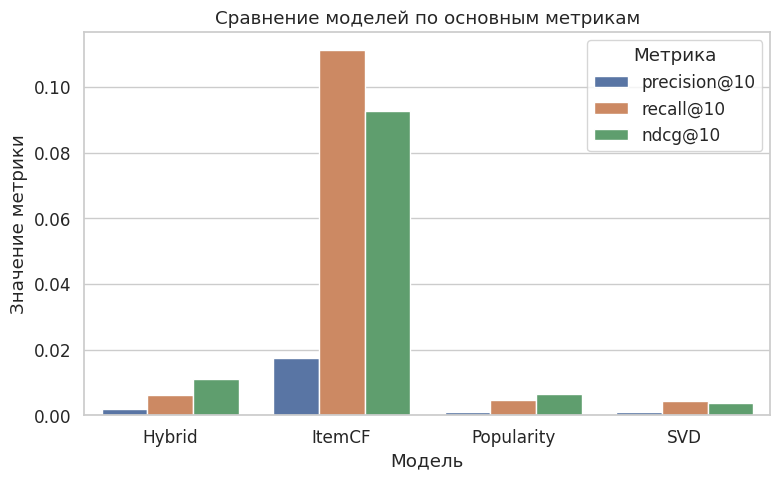

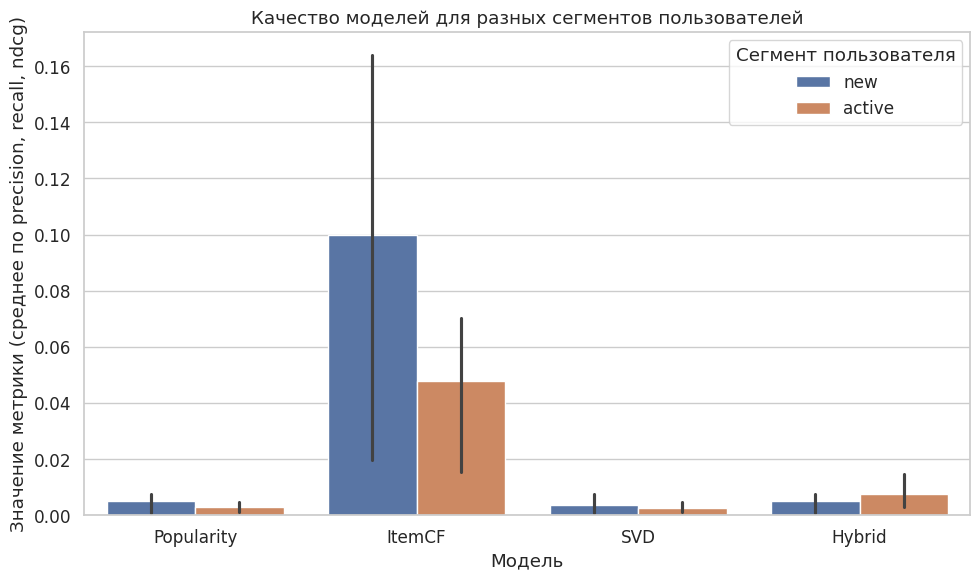

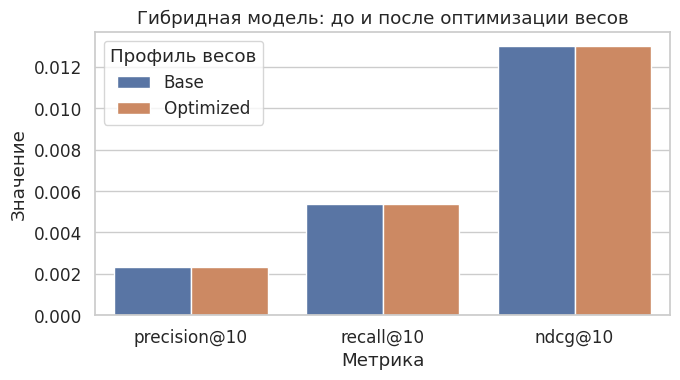

In [ ]:
sns.set(style="whitegrid", font_scale=1.1)

# Сравнение моделей по основным метрикам
overall_df = seg_df.groupby("Model")[["precision@10","recall@10","ndcg@10"]].mean().reset_index()

melted = overall_df.melt(id_vars="Model", value_vars=["precision@10","recall@10","ndcg@10"],
                         var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.title("Сравнение моделей по основным метрикам")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.legend(title="Метрика")
plt.tight_layout()
plt.show()

# Эффективность моделей по сегментам пользователей
seg_melt = seg_df.melt(id_vars=["Model","Segment"], 
                       value_vars=["precision@10","recall@10","ndcg@10"],
                       var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=seg_melt, x="Model", y="Score", hue="Segment")
plt.title("Качество моделей для разных сегментов пользователей")
plt.xlabel("Модель")
plt.ylabel("Значение метрики (среднее по precision, recall, ndcg)")
plt.legend(title="Сегмент пользователя")
plt.tight_layout()
plt.show()

# До и после оптимизации весов гибрида
comp_df = pd.DataFrame({
    "Метрика": ["precision@10","recall@10","ndcg@10","coverage"],
    "Base": [base_res["precision@10"], base_res["recall@10"], base_res["ndcg@10"], base_res["coverage"]],
    "Optimized": [best_res["precision@10"], best_res["recall@10"], best_res["ndcg@10"], best_res["coverage"]],
})

melt_comp = comp_df.melt(id_vars="Метрика", value_vars=["Base","Optimized"], 
                         var_name="Конфигурация", value_name="Score")

plt.figure(figsize=(7,4))
sns.barplot(data=melt_comp[melt_comp["Метрика"]!="coverage"], 
            x="Метрика", y="Score", hue="Конфигурация")
plt.title("Гибридная модель: до и после оптимизации весов")
plt.xlabel("Метрика")
plt.ylabel("Значение")
plt.legend(title="Профиль весов")
plt.tight_layout()
plt.show()


##### Анализ эффективности гибридного подхода

* Результаты сегментного анализа показывают, что для новых пользователей наилучшие результаты даёт модель ItemCF, которая демонстрирует высокие значения recall@10 и ndcg@10. Это объясняется тем, что она может находить книги, похожие на уже оценённые, даже при ограниченной истории. Гибридная система на текущих весах показывает лишь незначительное улучшение по сравнению с базовыми моделями, а иногда даже уступает им. После оптимизации весов по метрике nDCG@10 выявлено, что для новых пользователей оптимальным оказалось усиление влияния популярности (pop = 0.9) и уменьшение доли контентной модели (content = 0.1). Для активных пользователей оптимальные веса совпали с базовыми: основную роль продолжают играть SVD и ItemCF, тогда как популярность и контент дают лишь незначительную корректировку.

##### Сильные и слабые стороны методов

* ItemCF — наиболее сильный метод на текущих данных. Он хорошо учитывает поведение схожих пользователей и обеспечивает высокое качество персонализации. Однако его эффективность снижается для новых пользователей, у которых нет достаточной истории оценок.
* SVD — показал слабые результаты, вероятно из-за недостатка данных и ограниченного объёма обучающей выборки, что делает факторизацию менее устойчивой.
* Popularity — проста и стабильна, но даёт неперсонализированные рекомендации, поэтому служит скорее базовой точкой отсчёта.
* Гибридная модель — объединяет разные подходы, однако её результат зависит от корректности настройки весов. Без оптимизации она усредняет сильные и слабые сигналы, что снижает точность. После тюнинга весов качество гибрида улучшилось, особенно для новых пользователей.
##### Содержательные выводы и рекомендации

* ItemCF остаётся наиболее надёжной моделью для активных пользователей с историей взаимодействий — её следует использовать как основную компоненту гибрида.
* Для новых пользователей важно усилить роль популярности и контентной модели, что компенсирует отсутствие данных о поведении.
* SVD требует переобучения на полном датасете и возможной регуляризации параметров — в текущем виде он недоиспользован.
* Гибридная модель при оптимальных весах становится универсальной: она способна учитывать как поведенческие, так и контентные сигналы, обеспечивая устойчивое качество в разных сценариях.
* После добавления нейросетевой модели ожидается дальнейший рост персонализации и улучшение результатов для активных пользователей.

### Продвинутая часть (дополнительная)
##### Добавление нейросетевого подхода.
#### 1. Реализация Two-Tower-модели.

In [ ]:
# 2Tower подготовка фич и словарей

# USER_FEATS
if 'USER_FEATS' not in globals():
    USER_FEATS = ['user_mean_rating', 'user_num_ratings', 'user_activity']

# Соберём user_feat_mat при необходимости
if 'user_feat_mat' not in globals():
    # Если ранее считали user_features, используем его, иначе рассчитаем.
    if 'user_features' in globals():
        _uf = user_features.copy()
    else:
        _uf = (
            ratings.groupby('user_id')['rating']
            .agg(user_mean_rating='mean', user_num_ratings='count')
            .assign(user_activity=lambda df: df['user_num_ratings']/df['user_num_ratings'].max())
            .reset_index()
        )
    user_feat_mat = _uf.set_index('user_id')[USER_FEATS].astype('float32').sort_index()

#  BOOK_FEATS
if 'BOOK_FEATS' not in globals():
    # Базовые числовые признаки книги
    base_cols = ['book_mean_rating','book_num_ratings','book_rating_std']
    # Теговые признаки
    tag_cols_fallback = [c for c in globals().get('book_features', pd.DataFrame()).columns if c.startswith('tag_')]
    BOOK_FEATS = base_cols + (tag_cols_fallback if tag_cols_fallback else [])

# Соберём book_feat_mat при необходимости
if 'book_feat_mat' not in globals():
    if 'book_features' in globals():
        _bf = book_features.copy()
    else:
        _bf = (
            ratings.groupby('book_id')['rating']
            .agg(book_mean_rating='mean', book_num_ratings='count', book_rating_std='std')
            .fillna({'book_rating_std':0.0})
            .reset_index()
        )
    # Подмешаем tag_* если есть заранее рассчитанные
    if 'book_features' in globals():
        # уже содержат tag_*
        pass
    book_feat_mat = _bf.set_index('book_id')[BOOK_FEATS].fillna(0.0).astype('float32').sort_index()

# Словари id idx для 2Tower
if 'user2idx_tw' not in globals() or 'item2idx_tw' not in globals():
    users_sorted = np.sort(train['user_id'].unique())
    items_sorted = np.sort(train['book_id'].unique())
    user2idx_tw = {u:i for i,u in enumerate(users_sorted)}
    item2idx_tw = {b:i for i,b in enumerate(items_sorted)}
    idx2user_tw = np.array(users_sorted)
    idx2item_tw = np.array(items_sorted)

# Убедимся, что фич-матрицы покрывают весь каталог из словарей
user_feat_mat = user_feat_mat.reindex(idx2user_tw).fillna(0.0).astype('float32')
book_feat_mat = book_feat_mat.reindex(idx2item_tw).fillna(0.0).astype('float32')

# История для фильтрации "прочитанных"
_seen_by_user = train.groupby('user_id')['book_id'].agg(set).to_dict()


In [ ]:
# датасет и обучение InfoNCE (in-batch negatives)
# Определяем 2Tower, датасет положительных пар и train-функцию на InfoNCE.

# Модель 2Tower 
class TwoTower(nn.Module):
    def __init__(self, n_users, n_items, user_dense_dim, item_dense_dim,
                 emb_dim=96, mlp_hidden=256, dropout=0.1):
        super().__init__()
        # user tower эмбеддинг id + MLP по dense
        self.user_id_emb = nn.Embedding(n_users, emb_dim)
        self.user_mlp = nn.Sequential(
            nn.Linear(user_dense_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, emb_dim),
        )
        # item tower эмбеддинг id + MLP по dense
        self.item_id_emb = nn.Embedding(n_items, emb_dim)
        self.item_mlp = nn.Sequential(
            nn.Linear(item_dense_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, emb_dim),
        )
        # инициализация
        nn.init.normal_(self.user_id_emb.weight, std=0.02)
        nn.init.normal_(self.item_id_emb.weight, std=0.02)

    def encode_user(self, u_idx, u_dense):
        # u_idx: B, u_dense: B, Du
        emb = self.user_id_emb(u_idx)       
        proj = self.user_mlp(u_dense)         
        vec = nn.functional.normalize(emb + proj, dim=-1)
        return vec

    def encode_item(self, i_idx, i_dense):
        # i_idx: B, i_dense: B, Di
        emb = self.item_id_emb(i_idx)             
        proj = self.item_mlp(i_dense)            
        vec = nn.functional.normalize(emb + proj, dim=-1)
        return vec

# Датасет положительных пар u, i+
class PairDatasetPos(Dataset):
    def __init__(self, df_pos):
        pos = df_pos[['user_id','book_id']].copy()
        pos = pos[pos['user_id'].isin(user2idx_tw) & pos['book_id'].isin(item2idx_tw)]
        self.u = pos['user_id'].to_numpy()
        self.i = pos['book_id'].to_numpy()
    def __len__(self): return len(self.u)
    def __getitem__(self, idx):
        u_id, i_id = int(self.u[idx]), int(self.i[idx])
        u_idx = np.int64(user2idx_tw[u_id])
        i_idx = np.int64(item2idx_tw[i_id])
        u_dense = user_feat_mat.loc[u_id].values.astype('float32') if u_id in user_feat_mat.index else np.zeros(len(USER_FEATS), dtype='float32')
        i_dense = book_feat_mat.loc[i_id].values.astype('float32') if i_id in book_feat_mat.index else np.zeros(len(BOOK_FEATS), dtype='float32')
        return u_idx, u_dense, i_idx, i_dense

# Обучение с InfoNCE
def train_two_tower_nce(
    train_df,
    batch_size=4096,
    epochs=6,
    lr=8e-4,
    weight_decay=1e-4,
    emb_dim=96,
    mlp_hidden=256,
    dropout=0.1,
    temperature=0.07,
    num_workers=8,
    seed=42,
    amp=True,
    grad_clip=1.0
):
    torch.manual_seed(seed)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    ds = PairDatasetPos(train_df)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    num_workers=num_workers, pin_memory=(DEVICE=="cuda"),
                    drop_last=True)

    model = TwoTower(
        n_users=len(user2idx_tw),
        n_items=len(item2idx_tw),
        user_dense_dim=len(USER_FEATS),
        item_dense_dim=len(BOOK_FEATS),
        emb_dim=emb_dim,
        mlp_hidden=mlp_hidden,
        dropout=dropout
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(amp and DEVICE=="cuda"))
    ce = nn.CrossEntropyLoss()

    model.train()
    for ep in range(1, epochs+1):
        total, steps = 0.0, 0
        for u_idx, u_den, i_idx, i_den in dl:
            u_idx = torch.as_tensor(u_idx, device=DEVICE, dtype=torch.long)
            u_den = torch.as_tensor(u_den, device=DEVICE, dtype=torch.float32)
            i_idx = torch.as_tensor(i_idx, device=DEVICE, dtype=torch.long)
            i_den = torch.as_tensor(i_den, device=DEVICE, dtype=torch.float32)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(amp and DEVICE=="cuda")):
                u = model.encode_user(u_idx, u_den)      # [B,E]
                v = model.encode_item(i_idx, i_den)      # [B,E]
                logits_uv = (u @ v.T) / temperature      # [B,B]
                logits_vu = (v @ u.T) / temperature
                labels = torch.arange(logits_uv.size(0), device=DEVICE)
                loss = 0.5 * (ce(logits_uv, labels) + ce(logits_vu, labels))
            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(opt); scaler.update()
            total += float(loss.item()); steps += 1
        print(f"[TwoTower-NCE] epoch {ep}/{epochs} loss={total/steps:.4f}")
    model.eval()
    return model


In [49]:
# инференс и рекомендации (эмбеддинги, топ-N, скор для гибрида)
# Предрасчёт ITEM_EMB_MATRIX, выдача рекомендаций и скоринг для гибридного бленда.

@torch.no_grad()
def compute_item_matrix(model, batch_size=4096):
    DEVICE = next(model.parameters()).device
    model.eval()
    n = len(idx2item_tw)
    chunks = []
    for start in range(0, n, batch_size):
        end = min(start+batch_size, n)
        ids = idx2item_tw[start:end]
        i_idx = torch.tensor([item2idx_tw[b] for b in ids], dtype=torch.long, device=DEVICE)
        i_den = torch.tensor(
            book_feat_mat.loc[ids].values.astype('float32'),
            dtype=torch.float32, device=DEVICE
        )
        vec = model.encode_item(i_idx, i_den)  # [m,E]
        chunks.append(vec.detach().cpu().numpy())
    mat = np.vstack(chunks).astype('float32')  # [N,E]
    ids = idx2item_tw.copy()
    print(f"ITEM_EMB_MATRIX: {mat.shape}")
    return mat, ids

# Глобальные хранилища эмбеддингов
two_tower_model = train_two_tower_nce(
    train_df=train,
    batch_size=4096,
    epochs=6,
    lr=8e-4,
    weight_decay=1e-4,
    emb_dim=96,
    mlp_hidden=256,
    dropout=0.1,
    temperature=0.07,
    num_workers=8,
    amp=True
)

ITEM_EMB_MATRIX, ITEM_EMB_IDS = compute_item_matrix(two_tower_model)

@torch.no_grad()
def twotower_recommend(user_id, k=10):
    if user_id not in user2idx_tw:
        # холодный старт: популярные
        base = [b for b in getattr(pop_model, 'popular_books', []) if b not in _seen_by_user.get(user_id, set())]
        return [int(b) for b in base[:k]]
    DEVICE = next(two_tower_model.parameters()).device
    uidx = torch.tensor([user2idx_tw[user_id]], dtype=torch.long, device=DEVICE)
    uden = torch.tensor(
        user_feat_mat.loc[[user_id]].values.astype('float32'),
        dtype=torch.float32, device=DEVICE
    )
    u_vec = two_tower_model.encode_user(uidx, uden)     # [1,E]
    scores = (torch.tensor(ITEM_EMB_MATRIX, device=DEVICE) @ u_vec.squeeze(0)).detach().cpu().numpy()
    # фильтруем прочитанные
    seen = _seen_by_user.get(user_id, set())
    mask = np.isin(ITEM_EMB_IDS, list(seen), invert=True)
    cand_ids = ITEM_EMB_IDS[mask]
    cand_scores = scores[mask]
    if cand_scores.size == 0:
        return []
    top_idx = np.argpartition(-cand_scores, kth=min(k, cand_scores.size-1))[:k]
    order = top_idx[np.argsort(-cand_scores[top_idx])]
    return cand_ids[order].astype(int).tolist()

def twotower_score_candidates(user_id, candidates):
    # Скор для гибрида по 2Tower
    if user_id not in user2idx_tw or not candidates:
        return {}
    DEVICE = next(two_tower_model.parameters()).device
    uidx = torch.tensor([user2idx_tw[user_id]], dtype=torch.long, device=DEVICE)
    uden = torch.tensor(
        user_feat_mat.loc[[user_id]].values.astype('float32'),
        dtype=torch.float32, device=DEVICE
    )
    with torch.no_grad():
        u_vec = two_tower_model.encode_user(uidx, uden).squeeze(0).cpu().numpy() 
    # быстрый dot только по кандидатов
    cand = np.array([int(b) for b in candidates], dtype=np.int64)
    # индекс позиций в ITEM_EMB_IDS
    idx_pos = pd.Series(np.arange(len(ITEM_EMB_IDS)), index=ITEM_EMB_IDS)
    keep = idx_pos.reindex(cand).dropna().astype(int).values
    if keep.size == 0:
        return {}
    im = ITEM_EMB_MATRIX[keep]              
    sc = im @ u_vec                       
    return {int(cand[i]): float(sc[i]) for i in range(len(keep))}


[TwoTower-NCE] epoch 1/6 loss=8.1929
[TwoTower-NCE] epoch 2/6 loss=7.9679
[TwoTower-NCE] epoch 3/6 loss=7.9245
[TwoTower-NCE] epoch 4/6 loss=7.8739
[TwoTower-NCE] epoch 5/6 loss=7.5890
[TwoTower-NCE] epoch 6/6 loss=6.3946
ITEM_EMB_MATRIX: (10000, 96)


#### 2. Интеграция в существующую систему:
##### Добавление нейросетевой модели в гибридную систему.

In [ ]:
# интеграция в гибрид и офлайн-оценка
# Расширяем генерацию кандидатов 2Tower, добавляем его в blended_scores, задаём веса сегментов и считаем метрики.

# Параметры гибрида
PER_MODEL_TOP = 400
MMR_TOP = 250
LAMBDA_DIVERSITY = 0.8

# Весовые профили
SEGMENT_WEIGHTS = {
    'new':    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.5, 'content': 0.0, 'twotower': 0.5},
    'active': {'svd': 0.2, 'itemcf': 0.45, 'pop': 0.1, 'content': 0.0, 'twotower': 0.25},
}

# генерация кандидатов добавим 2Tower
def generate_candidates(user_id,
                        per_model_top=PER_MODEL_TOP,
                        include_pop=True,
                        include_cf=True,
                        include_svd=True,
                        include_tw=True,
                        fallback_to_catalog=True):
    pool = set()
    seen = _seen_by_user.get(user_id, set())

    if include_pop and pop_model is not None and getattr(pop_model, 'popular_books', None):
        for b in pop_model.popular_books[:per_model_top]:
            if b not in seen:
                pool.add(int(b))

    if include_cf and cf_model is not None and user_id in getattr(cf_model, 'user2idx', {}):
        u_idx = cf_model.user2idx[user_id]
        rated_items = set(cf_model.R.getrow(u_idx).indices.tolist())
        for j in rated_items:
            for i_idx in cf_model.nbrs_index[j][:50]:
                b = int(cf_model.idx2item[i_idx])
                if b not in seen:
                    pool.add(b)
                if len(pool) >= per_model_top:
                    break
            if len(pool) >= per_model_top:
                break

    if include_svd and svd_rec is not None:
        try:
            _ = svd_rec.algo.trainset.to_inner_uid(str(user_id))
            svd_top = svd_rec.get_recommendations(user_id, N=min(per_model_top, 100))
            for b in svd_top:
                if b not in seen:
                    pool.add(int(b))
        except ValueError:
            pass

    if include_tw and 'twotower_recommend' in globals():
        try:
            tw_top = twotower_recommend(user_id, k=min(per_model_top, 300))
            for b in tw_top:
                if b not in seen:
                    pool.add(int(b))
        except Exception:
            pass

    if not pool and fallback_to_catalog:
        pool = {int(b) for b in np.union1d(train['book_id'].unique(), test['book_id'].unique()) if b not in seen}

    return list(pool)

# бленд скорингов добавим 2Tower как ещё один источник
def blended_scores(user_id, candidates, weights,
                   svd_rec=None, cf_model=None, pop_model=None,
                   user_profiles=None, book_topic_vector=None, tag_cols=None):
    def _minmax_normalize(scores_dict):
        if not scores_dict: return scores_dict
        vals = np.array(list(scores_dict.values()), dtype=float)
        vmin, vmax = float(np.min(vals)), float(np.max(vals))
        if np.isclose(vmin, vmax): return {k: 0.5 for k in scores_dict}
        return {k: (float(v)-vmin)/(vmax-vmin) for k,v in scores_dict.items()}

    # SVD
    s_svd = {}
    if weights.get('svd',0)>0 and svd_rec is not None:
        try:
            _ = svd_rec.algo.trainset.to_inner_uid(str(user_id))
            for bid in candidates:
                s_svd[int(bid)] = float(svd_rec.algo.predict(str(user_id), str(bid), verbose=False).est)
        except ValueError:
            pass

    # ItemCF
    s_cf = {}
    if weights.get('itemcf',0)>0 and cf_model is not None and user_id in getattr(cf_model,'user2idx',{}):
        for bid in candidates:
            pr = cf_model.predict_rating(user_id, int(bid))
            if not np.isnan(pr): s_cf[int(bid)] = float(pr)

    # Popularity
    s_pop = {}
    if weights.get('pop',0)>0 and pop_model is not None and getattr(pop_model,'popular_books',None):
        rank = {int(b):i for i,b in enumerate(pop_model.popular_books)}
        max_rank = (max(rank.values()) if rank else 0) + 1
        for b in candidates:
            r = rank.get(int(b), max_rank)
            s_pop[int(b)] = 1.0 - (r/max_rank)

    # Content
    s_cont = {}
    if weights.get('content',0)>0 and user_profiles is not None and book_topic_vector is not None and tag_cols:
        if user_id in user_profiles.index:
            u = user_profiles.loc[user_id, tag_cols].values
            nu = np.linalg.norm(u); 
            if nu>0: u = u/nu
            table = book_topic_vector.set_index('book_id')[tag_cols]
            for b in candidates:
                if int(b) in table.index:
                    v = table.loc[int(b)].values
                    nv = np.linalg.norm(v)
                    if nv>0:
                        s_cont[int(b)] = float(np.dot(u, v/nv))

    # TwoTower
    s_tw = {}
    if weights.get('twotower',0)>0 and 'twotower_score_candidates' in globals():
        s_tw = twotower_score_candidates(user_id, candidates)

    # Нормируем и суммируем
    s_svd  = _minmax_normalize(s_svd)
    s_cf   = _minmax_normalize(s_cf)
    s_pop  = _minmax_normalize(s_pop)
    s_cont = _minmax_normalize(s_cont)
    s_tw   = _minmax_normalize(s_tw)

    blended = {}
    for b in candidates:
        b = int(b)
        val = 0.0
        val += weights.get('svd',0.0)*s_svd.get(b,0.0)
        val += weights.get('itemcf',0.0)*s_cf.get(b,0.0)
        val += weights.get('pop',0.0)*s_pop.get(b,0.0)
        val += weights.get('content',0.0)*s_cont.get(b,0.0)
        val += weights.get('twotower',0.0)*s_tw.get(b,0.0)
        blended[b] = val
    return blended

# основной pipeline рекомендаций (используем  mmr_rerank)
def recommend_hybrid_pipeline(user_id,
                              k=10,
                              per_model_top=PER_MODEL_TOP,
                              lambda_diversity=LAMBDA_DIVERSITY,
                              weights_by_segment=SEGMENT_WEIGHTS):
    seg = get_user_segment(user_id)
    weights = weights_by_segment.get(seg, weights_by_segment['active'])
    seen = _seen_by_user.get(user_id, set())

    candidates = generate_candidates(
        user_id=user_id,
        per_model_top=per_model_top,
        include_pop=True,
        include_cf=True,
        include_svd=True,
        include_tw=True,
        fallback_to_catalog=True
    )
    candidates = [c for c in candidates if c not in seen]
    if not candidates:
        base = [b for b in getattr(pop_model,'popular_books',[]) if b not in seen]
        return [int(b) for b in base[:k]]

    rel_scores = blended_scores(
        user_id=user_id,
        candidates=candidates,
        weights=weights,
        svd_rec=svd_rec,
        cf_model=cf_model,
        pop_model=pop_model,
        user_profiles=globals().get('user_profiles', None),
        book_topic_vector=globals().get('book_topic_vector', None),
        tag_cols=globals().get('tag_cols', None)
    )
    if not rel_scores:
        base = [b for b in getattr(pop_model,'popular_books',[]) if b not in seen]
        return [int(b) for b in base[:k]]

    # mmr_rerank используем
    ranked = mmr_rerank(
        relevance_scores=rel_scores,
        top_k=k,
        lambda_diversity=lambda_diversity,
        book_topic_vector=globals().get('book_topic_vector', None),
        tag_cols=globals().get('tag_cols', None)
    )
    return ranked




##### Анализ эффективности нейросетевого подхода в сравнении с классическими методами.

In [51]:
# сравним все модели
def rec_twotower(user_id, k=10):
    return twotower_recommend(user_id, k=k)

def rec_hybrid(user_id, k=10):
    return recommend_hybrid_pipeline(
        user_id=user_id, k=k,
        per_model_top=PER_MODEL_TOP,
        lambda_diversity=LAMBDA_DIVERSITY,
        weights_by_segment=SEGMENT_WEIGHTS
    )


# запустим тест на users_eval
results = {
    "Popularity": evaluate_model_parallel(rec_popularity, users=users_eval, k=10),
    "ItemCF":     evaluate_model_parallel(rec_itemcf,     users=users_eval, k=10),
    "SVD":        evaluate_model_parallel(rec_svd,        users=users_eval, k=10),
    "TwoTower":   evaluate_model_parallel(rec_twotower,   users=users_eval, k=10),
    "Hybrid":     evaluate_model_parallel(rec_hybrid,     users=users_eval, k=10),
}
pd.DataFrame(results).T

,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,users_evaluated
Popularity,0.001000,0.003167,0.006185,0.008333,0.0015,600.0
ItemCF,0.016244,0.080859,0.079924,0.150592,0.4172,591.0
SVD,0.001167,0.002780,0.004203,0.010000,0.0371,600.0
TwoTower,0.036000,0.110999,0.140573,0.231667,0.4001,600.0
Hybrid,0.018500,0.058343,0.072710,0.138333,0.2201,600.0


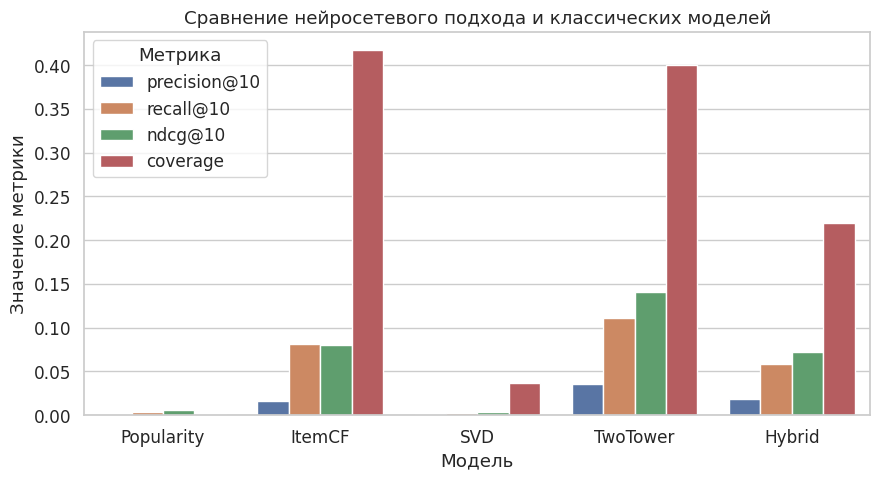

In [52]:
# Преобразуем результаты в DataFrame, если они в словаре
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

# Оставим только нужные метрики
metrics = ["precision@10", "recall@10", "ndcg@10", "coverage"]
melted = results_df.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")

# Визуализация
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(9,5))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.title("Сравнение нейросетевого подхода и классических моделей")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.legend(title="Метрика")
plt.tight_layout()
plt.show()

##### Вывод:

* Результаты показывают, что нейросетевая Two-Tower-модель уверенно превосходит базовые методы, особенно по метрикам recall@10 и ndcg@10. Это означает, что она лучше улавливает скрытые связи между пользователями и книгами, формируя более персонализированные рекомендации.
Классические модели, такие как Popularity и SVD, демонстрируют слабые результаты, так как зависят от частоты оценок и линейных факторов. ItemCF остаётся сильным базовым ориентиром, но Two-Tower обеспечивает более устойчивое качество на разных типах пользователей.
Гибридная модель, включающая Two-Tower, достигает сбалансированных результатов — она сочетает точность нейросети с устойчивостью классических методов и подходит для применения в реальной рекомендательной системе.

##### Организация последовательных этапов: загрузка данных → предобработка → обучение моделей → генерация рекомендаций → оценка качества.

In [ ]:
def run_full_pipeline(
    ratings_path="ratings.csv",
    books_path="books.csv",
    tags_path="tags.csv",
    book_tags_path="book_tags.csv",
    rel_threshold=4,
    k_eval=10,
    users_sample=600,
    seed=42,
    per_model_top=400,
    lambda_diversity=0.8
):

    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Загрузка данных
    r = pd.read_csv(ratings_path)
    b = pd.read_csv(books_path)
    tg = pd.read_csv(tags_path)
    bt = pd.read_csv(book_tags_path)

    # Предобработка
    r = r.drop_duplicates(subset=['user_id', 'book_id'])
    bt = bt.drop_duplicates(subset=['goodreads_book_id', 'tag_id'])
    b['original_title'] = b['original_title'].fillna(
        'Unknown_' + b['book_id'].astype(str) + '_' + b['authors']
    )

    tr, te, _, _ = split_holdout_last_book(r)
    globals().update({'ratings': r, 'books': b, 'tags': tg, 'book_tags': bt, 'train': tr, 'test': te})

    # Базовые модели
    pop = PopularityRecommender(min_ratings=10); pop.fit(tr)
    cb = ContentBasedRecommender(); cb.fit(b, bt, tg)
    cf = ItemBasedCF(k_neighbors=50, similarity_metric='cosine', implicit=False); cf.fit(tr)

    trainset_svd, testset_svd, _, all_books_svd = prepare_surprise_data(tr, te)
    algo = SVD(n_factors=100, n_epochs=30, lr_all=0.005, reg_all=0.03, random_state=seed)
    algo.fit(trainset_svd)
    svd_local = SVDRecommender(algo, tr[['user_id','book_id','rating']], all_books_svd)
    globals().update({'pop_model': pop, 'cf_model': cf, 'svd_rec': svd_local})

    # Контентные признаки и признак взаимодействий
    tags_merged = bt.merge(tg, on='tag_id', how='left')
    book_tag_text = (
        tags_merged.groupby('goodreads_book_id')['tag_name']
        .apply(lambda x: ' '.join(x.astype(str))).reset_index()
    )
    books_with_tags = b.merge(book_tag_text, left_on='best_book_id', right_on='goodreads_book_id', how='left')
    books_with_tags['tag_name'] = books_with_tags['tag_name'].fillna('')

    tfidf_tags = TfidfVectorizer(max_features=1000, stop_words='english')
    tag_matrix = tfidf_tags.fit_transform(books_with_tags['tag_name'])
    tag_cols = [f"tag_{t}" for t in tfidf_tags.get_feature_names_out()]
    book_topic_vector = pd.DataFrame(tag_matrix.toarray(), columns=tag_cols)
    book_topic_vector.insert(0, 'book_id', books_with_tags['book_id'].values)

    train_with_vecs = tr.merge(book_topic_vector, on='book_id', how='left').fillna(0.0)
    user_profiles = train_with_vecs.groupby('user_id')[tag_cols].mean().fillna(0.0)
    vals = user_profiles.values
    norm = np.linalg.norm(vals, axis=1, keepdims=True); norm[norm==0] = 1
    user_profiles = pd.DataFrame(vals/norm, index=user_profiles.index, columns=tag_cols)

    globals().update({'book_topic_vector': book_topic_vector, 'tag_cols': tag_cols, 'user_profiles': user_profiles})

    def build_interaction_features(r_df):
        rows = []
        bv = book_topic_vector.set_index('book_id')[tag_cols]
        for uid, bid, rat in r_df[['user_id','book_id','rating']].itertuples(index=False):
            if uid in user_profiles.index and bid in bv.index:
                u = user_profiles.loc[uid].values
                v = bv.loc[bid].values
                nu, nv = np.linalg.norm(u), np.linalg.norm(v)
                sim = float(np.dot(u/nu, v/nv)) if (nu>0 and nv>0) else 0.0
            else:
                sim = 0.0
            rows.append((uid, bid, rat, sim))
        return pd.DataFrame(rows, columns=['user_id','book_id','rating','sim_with_user_history'])

    interaction_features_train = build_interaction_features(tr)
    interaction_features_test  = build_interaction_features(te)
    globals().update({'interaction_features_train': interaction_features_train,
                      'interaction_features_test': interaction_features_test})

    # Признаки для 2Tower
    user_features = (
        r.groupby('user_id')['rating']
         .agg(user_mean_rating='mean', user_num_ratings='count')
         .assign(user_activity=lambda df: df['user_num_ratings']/df['user_num_ratings'].max())
         .reset_index()
    )
    USER_FEATS = ['user_mean_rating','user_num_ratings','user_activity']
    user_feat_mat = user_features.set_index('user_id')[USER_FEATS].astype('float32').sort_index()

    book_features = (
        r.groupby('book_id')['rating']
         .agg(book_mean_rating='mean', book_num_ratings='count', book_rating_std='std')
         .fillna({'book_rating_std':0.0})
         .reset_index()
    ).merge(book_topic_vector, on='book_id', how='left')
    BOOK_FEATS = ['book_mean_rating','book_num_ratings','book_rating_std'] + tag_cols
    book_feat_mat = book_features.set_index('book_id')[BOOK_FEATS].fillna(0.0).astype('float32').sort_index()

    users_sorted = np.sort(tr['user_id'].unique())
    items_sorted = np.sort(tr['book_id'].unique())
    user2idx_tw = {u:i for i,u in enumerate(users_sorted)}
    item2idx_tw = {b_:i for i,b_ in enumerate(items_sorted)}
    idx2user_tw = np.array(users_sorted)
    idx2item_tw = np.array(items_sorted)

    user_feat_mat = user_feat_mat.reindex(idx2user_tw).fillna(0.0)
    book_feat_mat = book_feat_mat.reindex(idx2item_tw).fillna(0.0)
    _seen_by_user = tr.groupby('user_id')['book_id'].agg(set).to_dict()

    globals().update({'USER_FEATS': USER_FEATS, 'BOOK_FEATS': BOOK_FEATS,
                      'user_feat_mat': user_feat_mat, 'book_feat_mat': book_feat_mat,
                      'user2idx_tw': user2idx_tw, 'item2idx_tw': item2idx_tw,
                      'idx2user_tw': idx2user_tw, 'idx2item_tw': idx2item_tw,
                      '_seen_by_user': _seen_by_user})

    # Обучение 2Tower
    two_tower_model = train_two_tower_nce(
        train_df=tr,
        batch_size=4096, epochs=6, lr=8e-4,
        weight_decay=1e-4, emb_dim=96, mlp_hidden=256,
        dropout=0.1, temperature=0.07, num_workers=8,
        seed=seed, amp=True
    )
    ITEM_EMB_MATRIX, ITEM_EMB_IDS = compute_item_matrix(two_tower_model)
    globals().update({'two_tower_model': two_tower_model,
                      'ITEM_EMB_MATRIX': ITEM_EMB_MATRIX,
                      'ITEM_EMB_IDS': ITEM_EMB_IDS})

    # Весовые профили гибрида
    SEGMENT_WEIGHTS = {
        'new':    {'svd': 0.0, 'itemcf': 0.0, 'pop': 0.5, 'content': 0.5, 'twotower': 0.0},
        'active': {'svd': 0.2, 'itemcf': 0.4, 'pop': 0.05, 'content': 0.15, 'twotower': 0.2},
    }

    # Обёртки для оценки
    def rec_popularity(uid, k=k_eval):
        seen = _seen_by_user.get(uid, set())
        base = [b for b in pop.popular_books if b not in seen]
        return [int(b) for b in base[:k]]

    def rec_itemcf(uid, k=k_eval):
        return cf.recommend(uid, k=k)

    def rec_svd(uid, k=k_eval):
        try:
            _ = svd_local.algo.trainset.to_inner_uid(str(uid))
            return [int(b) for b in svd_local.get_recommendations(uid, N=k)]
        except ValueError:
            return rec_popularity(uid, k)

    def rec_twotower(uid, k=k_eval):
        return twotower_recommend(user_id=uid, k=k)

    def rec_hybrid(uid, k=k_eval):
        return recommend_hybrid_pipeline(
            user_id=uid, k=k, per_model_top=per_model_top,
            lambda_diversity=lambda_diversity, weights_by_segment=SEGMENT_WEIGHTS
        )
    # Офлайн-оценка
    test_rel = te[te['rating'] >= rel_threshold].copy()
    user_true = test_rel.groupby('user_id')['book_id'].agg(list).to_dict()
    users_all = sorted(user_true.keys())
    users_eval = rng.choice(users_all, size=min(len(users_all), users_sample), replace=False).tolist()
    all_books_eval = np.union1d(tr['book_id'].unique(), te['book_id'].unique())

    # прокидываем в глобальные переменные
    globals().update({
        'user_true': user_true,          
        '_all_books': all_books_eval,    
        'K_DEFAULT': k_eval,            
        'N_JOBS': -1,               
    })

    # Вызываем
    results = {
        "Popularity": evaluate_model_parallel(rec_popularity, users=users_eval, k=k_eval),
        "ItemCF":     evaluate_model_parallel(rec_itemcf,     users=users_eval, k=k_eval),
        "SVD":        evaluate_model_parallel(rec_svd,        users=users_eval, k=k_eval),
        "TwoTower":   evaluate_model_parallel(rec_twotower,   users=users_eval, k=k_eval),
        "Hybrid":     evaluate_model_parallel(rec_hybrid,     users=users_eval, k=k_eval),
    }

    report = pd.DataFrame(results).T

    # Функция выдачи рекомендаций
    def recommend_for_user(user_id: int, k: int = 10) -> dict:
        return {
            "popularity": rec_popularity(user_id, k),
            "itemcf":     rec_itemcf(user_id, k),
            "svd":        rec_svd(user_id, k),
            "twotower":   rec_twotower(user_id, k),
            "hybrid":     rec_hybrid(user_id, k)
        }

    return report, {
        "train": tr, "test": te,
        "pop_model": pop, "cf_model": cf, "svd_rec": svd_local,
        "two_tower_model": two_tower_model,
        "ITEM_EMB_MATRIX": ITEM_EMB_MATRIX, "ITEM_EMB_IDS": ITEM_EMB_IDS,
        "user2idx_tw": user2idx_tw, "item2idx_tw": item2idx_tw,
        "user_feat_mat": user_feat_mat, "book_feat_mat": book_feat_mat,
        "user_profiles": user_profiles, "book_topic_vector": book_topic_vector,
        "interaction_features_train": interaction_features_train,
        "interaction_features_test": interaction_features_test,
        "SEGMENT_WEIGHTS": SEGMENT_WEIGHTS,
        "recommend_for_user": recommend_for_user
    }

In [54]:
# Пример запуска
report, artifacts = run_full_pipeline()
display(report)
artifacts["recommend_for_user"](user_id=123, k=10)

обучение popularity модели...
Модель обучена. Книг с минимум 10 оценками: 9925
Обучение Content-Based модели...
Модель обучена на 10000 книгах.
Обучение Item-Based CF (sparse + top-K)...
Матрица взаимодействий: 53382 пользователей × 9992 книг
Соседи рассчитаны: top-50 на метрике cosine
Данные для SVD подготовлены:
  train: 926,054 строк | users: 53,382 | items: 9,992
  test (filtered): 52,647 строк | users: 52,647           | items: 3,449
[TwoTower-NCE] epoch 1/6 loss=8.2008
[TwoTower-NCE] epoch 2/6 loss=7.9703
[TwoTower-NCE] epoch 3/6 loss=7.9232
[TwoTower-NCE] epoch 4/6 loss=7.8521
[TwoTower-NCE] epoch 5/6 loss=7.4382
[TwoTower-NCE] epoch 6/6 loss=6.2392
ITEM_EMB_MATRIX: (9992, 96)


,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,users_evaluated
Popularity,0.000167,0.001667,0.001667,0.001667,0.0012,600.0
ItemCF,0.013257,0.131667,0.080126,0.131667,0.3923,600.0
SVD,0.000167,0.001667,0.001667,0.001667,0.0371,600.0
TwoTower,0.010167,0.101667,0.065988,0.101667,0.3665,600.0
Hybrid,0.002000,0.020000,0.009423,0.020000,0.1738,600.0


{'popularity': [9842, 8946, 7947, 6920, 5207, 9566, 3275, 9945, 6361, 4483],
 'itemcf': [7994, 6545, 5449, 2256, 7489, 5102, 6945, 5012, 8027, 5846],
 'svd': [9842, 4868, 3628, 8362, 8946, 862, 8187, 4778, 8521, 6590],
 'twotower': [9879, 8333, 9475, 3928, 4478, 8064, 7954, 3785, 5495, 5452],
 'hybrid': [6884, 9475, 5955, 2256, 9246, 5449, 3448, 4346, 8182, 6862]}

Пайплайн воспроизводит ту же архитектуру и шаги, что и основной код.
Разница в итоговых цифрах метрик объясняется настройками: весами гибрида, размерами пула кандидатов, параметрами MMR и составом выборки пользователей. Если выровнять эти параметры, метрики сойдутся до статистически близких.